# Preprocess

In [1]:
from preprocess import run_full_pipeline
resultats = run_full_pipeline(r"C:\TSQ\data\Projet_final_DESU\data2.csv")

df = resultats["df"]
df_PS = resultats["df_PS"]
df_PD = resultats["df_PD"]

df_SD = resultats["df_SD"]
df_SD_PS = resultats["df_SD_PS"]
df_SD_PD = resultats["df_SD_PD"]

df_BAI = resultats["df_BAI"]
df_TSQ = resultats["df_TSQ"]
df_TSQ_PD = resultats["df_TSQ_PD"]

df_EP = resultats["df_EP"]
df_EP_PD = resultats["df_EP_PD"]

df_16 = resultats["df_16"]
df_16_PD = resultats["df_16_PD"]
echelle1 = resultats["echelle1"]
echelle2 = resultats["echelle2"]

df_sub = resultats["df_sub"]

df_ZTPI = resultats["df_ZTPI"]
df_ZTPI_PD = resultats["df_ZTPI_PD"]


Shape : (201, 272) | PS : 166 | PD : 35 (17.4% avec diagnostic)
Nombre de lignes complètement vides : 0


# Création de groupes au sein de l'échelle TSQ: 
* 0 = personne saine 
* 1 = personne se déclarant avec diagnostique

In [2]:
import pandas as pd
df_TSQ = df_TSQ.copy()
df_TSQ["group"] = 0

df_TSQ_PD = df_TSQ_PD.copy()
df_TSQ_PD["group"] = 1

df_all = pd.concat([df_TSQ, df_TSQ_PD])
group = df_all["group"]          
df_all = df_all.drop(columns="group")   


On renomme les colonnes : intitulé des questions --> TSQ1 +n

In [3]:
dfs = [df_TSQ, df_TSQ_PD, df_all]

for df in dfs:
    
    cols_tsq_brutes = df.columns[0:40]

    # On renomme les 40 items : TSQ1 → TSQ40
    new_names = [f"TSQ{i}" for i in range(1, 41)]
    df.rename(columns=dict(zip(cols_tsq_brutes, new_names)), inplace=True)

    df[new_names] = df[new_names].apply(
        lambda col: col.astype(str).str.extract(r"(\d+)")[0].astype(float)
    )


# Correlation des 40x40 items de la TSQ + greedy glouton pour la redondance des corrélations

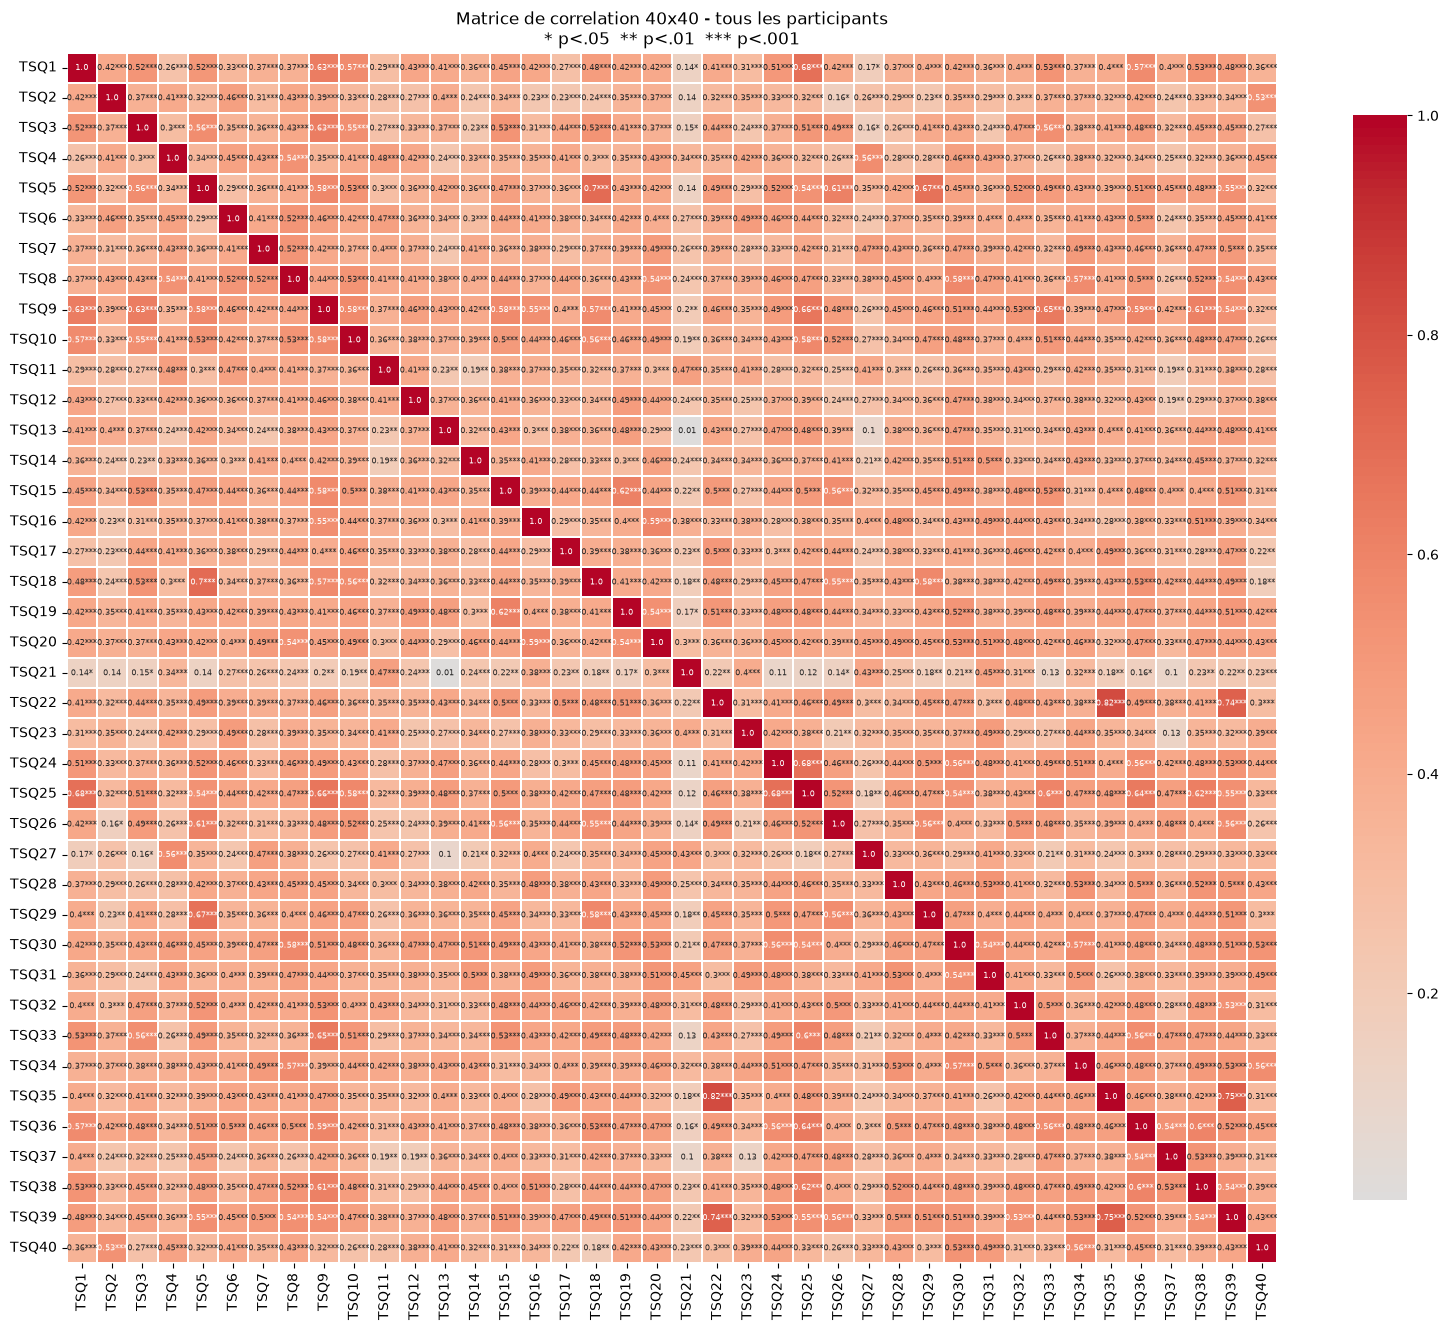

Items conservés : ['TSQ1', 'TSQ2', 'TSQ3', 'TSQ4', 'TSQ6', 'TSQ7', 'TSQ8', 'TSQ10', 'TSQ11', 'TSQ12', 'TSQ13', 'TSQ14', 'TSQ15', 'TSQ16', 'TSQ17', 'TSQ18', 'TSQ19', 'TSQ20', 'TSQ21', 'TSQ23', 'TSQ24', 'TSQ26', 'TSQ27', 'TSQ28', 'TSQ29', 'TSQ30', 'TSQ31', 'TSQ32', 'TSQ33', 'TSQ34', 'TSQ35', 'TSQ36', 'TSQ37', 'TSQ38', 'TSQ40']
Items retirés : ['TSQ5', 'TSQ9', 'TSQ22', 'TSQ25', 'TSQ39']


In [4]:
from correl_TSQ import compute_tsq_corr

compute_tsq_corr(df_all, items=[f"TSQ{i}" for i in range(1, 41)], title="Matrice de correlation 40x40 - tous les participants")

from correl_TSQ import reduce_correlated_features
items = [f"TSQ{i}" for i in range(1, 41)]
selected_items = reduce_correlated_features(df_all, items, threshold=0.65)

print("Items conservés :", selected_items)
print("Items retirés :", [i for i in items if i not in selected_items])



# VIF pour voir la multicollinéarité

In [5]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = df_all[items].dropna()
vif_data = pd.DataFrame()
vif_data['item'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print(vif_data.sort_values('VIF', ascending=False))

     item       VIF
34  TSQ35  4.764800
21  TSQ22  4.675965
38  TSQ39  4.496535
24  TSQ25  4.354132
8    TSQ9  4.303083
4    TSQ5  3.961502
29  TSQ30  3.546883
7    TSQ8  3.378854
35  TSQ36  3.272848
37  TSQ38  3.156585
17  TSQ18  3.154760
25  TSQ26  3.012855
14  TSQ15  3.002561
23  TSQ24  2.970287
19  TSQ20  2.958369
39  TSQ40  2.945787
32  TSQ33  2.853671
9   TSQ10  2.821296
31  TSQ32  2.809845
33  TSQ34  2.793588
2    TSQ3  2.780620
3    TSQ4  2.761665
18  TSQ19  2.747349
30  TSQ31  2.722474
0    TSQ1  2.627549
28  TSQ29  2.560160
5    TSQ6  2.447231
26  TSQ27  2.408427
1    TSQ2  2.365887
27  TSQ28  2.363400
15  TSQ16  2.326067
22  TSQ23  2.304005
36  TSQ37  2.240877
16  TSQ17  2.172086
6    TSQ7  2.151581
12  TSQ13  2.149983
11  TSQ12  2.114850
13  TSQ14  2.110711
20  TSQ21  1.876214
10  TSQ11  1.734090


In [6]:
colonnes_a_exclure = ['TSQ5', 'TSQ9', 'TSQ22', 'TSQ25', 'TSQ39', 'score_total']  
df_red_sains = df_TSQ.drop(columns=colonnes_a_exclure)
df_red_pd = df_TSQ_PD.drop(columns=colonnes_a_exclure)

# methodes de la silhouette score, du coude, indice de Davies-Bouldin, indice de Calinski-Harabasz pour déterminer combien de k doit on prendre pour le K-means (étape d'après)

k=2 | inertie=27617.2 | silhouette=0.313 | davies-bouldin=1.441 | calinski-harabasz=74.2
k=3 | inertie=25080.7 | silhouette=0.226 | davies-bouldin=2.083 | calinski-harabasz=48.9
k=4 | inertie=23816.3 | silhouette=0.154 | davies-bouldin=2.537 | calinski-harabasz=37.0
k=5 | inertie=22896.8 | silhouette=0.149 | davies-bouldin=2.638 | calinski-harabasz=30.3
k=6 | inertie=22405.3 | silhouette=0.137 | davies-bouldin=2.666 | calinski-harabasz=25.3
k=7 | inertie=21903.2 | silhouette=0.079 | davies-bouldin=2.607 | calinski-harabasz=22.0
k=8 | inertie=21324.6 | silhouette=0.117 | davies-bouldin=2.524 | calinski-harabasz=19.9
k=9 | inertie=21062.4 | silhouette=0.066 | davies-bouldin=2.640 | calinski-harabasz=17.8
k=10 | inertie=20385.8 | silhouette=0.114 | davies-bouldin=2.356 | calinski-harabasz=16.8


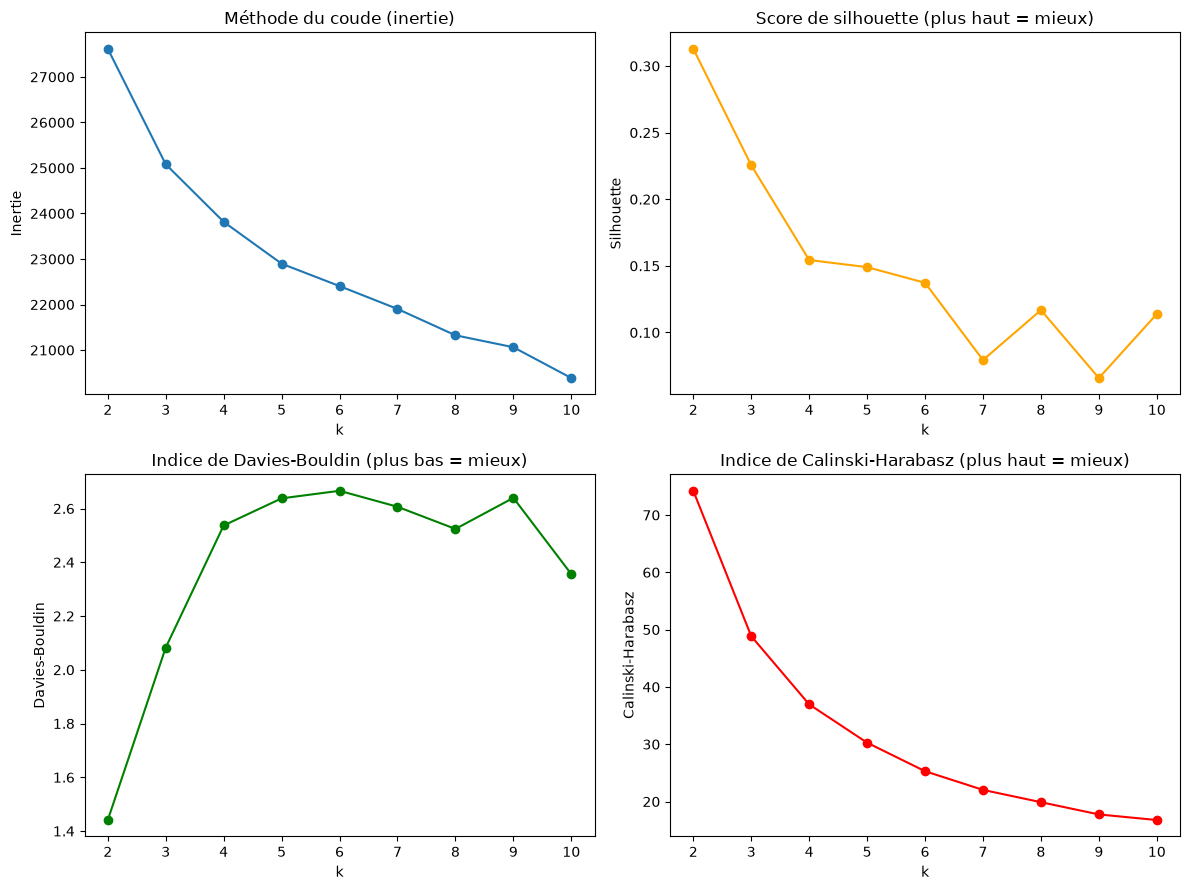


Meilleur k selon chaque indice :
  Silhouette (max)        : k=2 (score=0.313)
  Davies-Bouldin (min)    : k=2 (score=1.441)
  Calinski-Harabasz (max) : k=2 (score=74.2)


,k,inertie,silhouette,davies_bouldin,calinski_harabasz
0,2,27617.155397,0.312913,1.441099,74.226369
1,3,25080.707274,0.225533,2.082805,48.859521
2,4,23816.304250,0.154370,2.537057,36.958715
3,5,22896.823124,0.149050,2.637920,30.270532
4,6,22405.258384,0.137274,2.666049,25.296085
5,7,21903.224574,0.079306,2.606596,22.035862
6,8,21324.610786,0.116807,2.524123,19.890808
7,9,21062.387451,0.065813,2.639761,17.753941
8,10,20385.783356,0.113873,2.355941,16.776501


In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import matplotlib.pyplot as plt
import numpy as np

X = df_red_sains.values  

k_values = range(2, 11)
inerties = []
silhouettes = []
davies_bouldin = []
calinski_harabasz = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X)

    inerties.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(X, labels))
    davies_bouldin.append(davies_bouldin_score(X, labels))
    calinski_harabasz.append(calinski_harabasz_score(X, labels))

    print(f"k={k} | inertie={kmeans.inertia_:.1f} | silhouette={silhouettes[-1]:.3f} "
          f"| davies-bouldin={davies_bouldin[-1]:.3f} | calinski-harabasz={calinski_harabasz[-1]:.1f}")


resultats_k = pd.DataFrame({
    "k": list(k_values),
    "inertie": inerties,
    "silhouette": silhouettes,
    "davies_bouldin": davies_bouldin,
    "calinski_harabasz": calinski_harabasz,
})

fig, axes = plt.subplots(2, 2, figsize=(12, 9))

axes[0, 0].plot(k_values, inerties, marker="o")
axes[0, 0].set_title("Méthode du coude (inertie)")
axes[0, 0].set_xlabel("k")
axes[0, 0].set_ylabel("Inertie")

axes[0, 1].plot(k_values, silhouettes, marker="o", color="orange")
axes[0, 1].set_title("Score de silhouette (plus haut = mieux)")
axes[0, 1].set_xlabel("k")
axes[0, 1].set_ylabel("Silhouette")

axes[1, 0].plot(k_values, davies_bouldin, marker="o", color="green")
axes[1, 0].set_title("Indice de Davies-Bouldin (plus bas = mieux)")
axes[1, 0].set_xlabel("k")
axes[1, 0].set_ylabel("Davies-Bouldin")

axes[1, 1].plot(k_values, calinski_harabasz, marker="o", color="red")
axes[1, 1].set_title("Indice de Calinski-Harabasz (plus haut = mieux)")
axes[1, 1].set_xlabel("k")
axes[1, 1].set_ylabel("Calinski-Harabasz")

for ax in axes.flat:
    ax.set_xticks(list(k_values))

plt.tight_layout()
plt.show()

# Meilleur k selon chaque indice
print("\nMeilleur k selon chaque indice :")
print(f"  Silhouette (max)        : k={resultats_k.loc[resultats_k['silhouette'].idxmax(), 'k']} "
      f"(score={resultats_k['silhouette'].max():.3f})")
print(f"  Davies-Bouldin (min)    : k={resultats_k.loc[resultats_k['davies_bouldin'].idxmin(), 'k']} "
      f"(score={resultats_k['davies_bouldin'].min():.3f})")
print(f"  Calinski-Harabasz (max) : k={resultats_k.loc[resultats_k['calinski_harabasz'].idxmax(), 'k']} "
      f"(score={resultats_k['calinski_harabasz'].max():.1f})")

resultats_k

Donc on va prendre k = 2 pour le clustering

# UMAP sur tous les participants sains sur le df reduit (35 items)

In [8]:
from umap_clustering import run_umap_clustering

result = run_umap_clustering(
    df_red_sains,
    n_clusters=2,
    random_state=42,
    group=group,
)


df_clust = result.df_clust         
clusters = result.clusters          
proj_2d = result.proj_2d            
proj_3d = result.proj_3d            
fig_2d, fig_3d = result.fig_2d, result.fig_3d

c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


cluster
0    103
1     63
Name: count, dtype: int64
Cluster 0: 103 participants (group 0: 103)
Cluster 1: 63 participants (group 0: 63)


# Split train/test des participants sains + entrainement des modeles classifier (4 différents) sur le train et test pour voir si l'algo me classe bien dans le bon cluster (par rapport au UMAP) les participants. Grid search pour trouver le meilleur modele

c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


cluster
0    103
1     63
Name: count, dtype: int64
Cluster 0: 103 participants (group 0: 103)
Cluster 1: 63 participants (group 0: 63)

=== LogisticRegression ===


c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


Meilleurs params : {'clf__C': 0.1, 'clf__penalty': 'l2'}
Meilleur score CV : 0.958 ±  0.038
Score sur test set : 0.962


c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Li

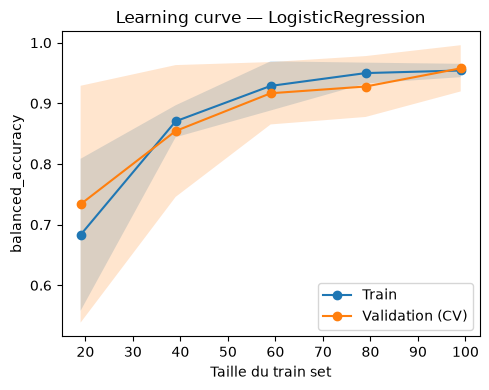


=== SVM_RBF ===


c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


Meilleurs params : {'clf__C': 1, 'clf__gamma': 0.1}
Meilleur score CV : 0.955 ±  0.057
Score sur test set : 0.962


c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1

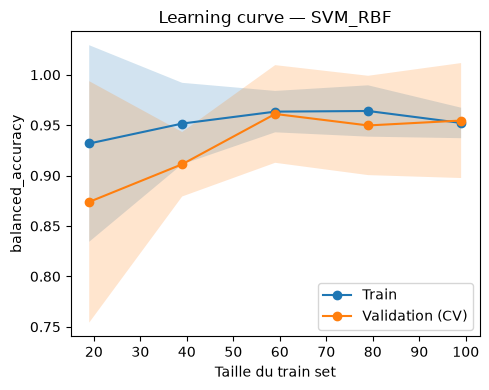


=== RandomForest ===
Meilleurs params : {'clf__max_depth': None, 'clf__min_samples_leaf': 5, 'clf__n_estimators': 100}
Meilleur score CV : 0.955 ±  0.045
Score sur test set : 0.962


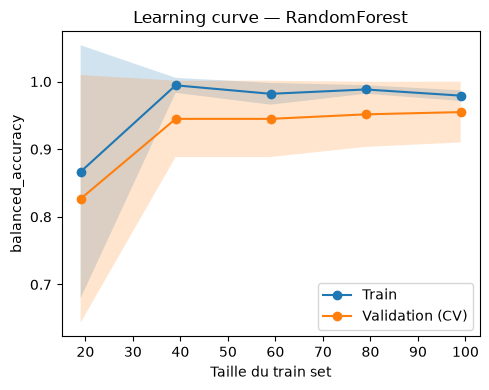


=== HistGradientBoosting ===
Meilleurs params : {'clf__learning_rate': 0.01, 'clf__max_depth': None, 'clf__max_iter': 100}
Meilleur score CV : 0.944 ±  0.039
Score sur test set : 0.962


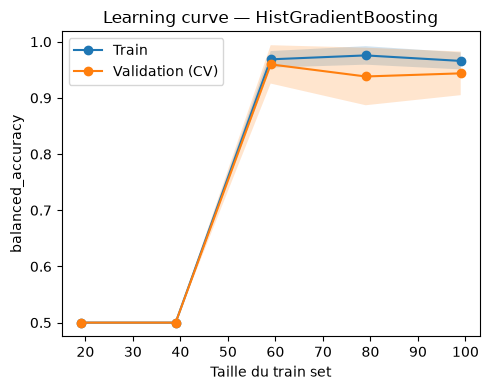


=== Comparaison des modèles ===
                      CV score    CV std  Test score
LogisticRegression    0.957778  0.038103    0.961538
RandomForest          0.954861  0.044898    0.961538
SVM_RBF               0.954583  0.057015    0.961538
HistGradientBoosting  0.943750  0.038814    0.961538

Meilleur modèle : LogisticRegression
              precision    recall  f1-score   support

           0       1.00      0.92      0.96        26
           1       0.89      1.00      0.94        16

    accuracy                           0.95        42
   macro avg       0.94      0.96      0.95        42
weighted avg       0.96      0.95      0.95        42



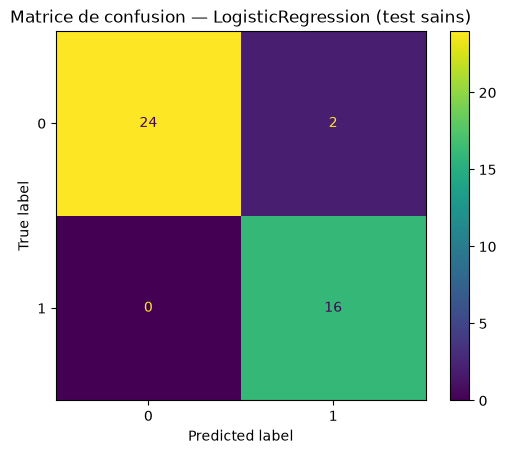

In [9]:
from sklearn.model_selection import train_test_split
from umap_clustering import run_umap_clustering
from machinelearning import train_and_compare_classifiers, apply_to_patients

# resultat du umap
result = run_umap_clustering(
    df_red_sains, n_clusters=2, random_state=42, group=group, show=False,
)

# reprend les resultats umap pour voir ou sont repartis les participants cluster 0 ou 1
X_all = result.proj_2d
y_all = result.clusters

# Split train/test SUR les projections/labels déjà calculés 
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all,
    test_size=0.25,
    random_state=42,
    stratify=y_all,  # garde la proportion des clusters
)

# Entraîne et compare les classifieurs
results, summary, best_model_name, best_model = train_and_compare_classifiers(
    X_train, y_train, X_test, y_test, scoring="balanced_accuracy"
)

Clairement overfit 

# Réprésentation de la prédiction de la répartition des patients sur les clusters 0 ou 1 dans l'espace UMAP des participants sains

In [10]:
X_patients_2d = result.umap_2d_model.transform(df_red_pd.values) #  Projete les patients dans l'espace UMAP appris sur les sains (transform, pas fit)

y_pred_patients = best_model.predict(X_patients_2d) # Applique le best modèle de classif pour prédire leur "cluster" 

df_patients_clust = df_red_pd.copy()
df_patients_clust['cluster_pred'] = y_pred_patients

print(df_patients_clust['cluster_pred'].value_counts().sort_index())

cluster_pred
0    15
1    20
Name: count, dtype: int64


In [11]:
from sklearn.model_selection import train_test_split
X_all = result.proj_2d
y_all = result.clusters
idx_all = df_red_sains.index

X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X_all, y_all, idx_all,
    test_size=0.25,
    random_state=42,
    stratify=y_all,
)


X_patients_umap = result.umap_2d_model.transform(df_red_pd.values)

import plotly.express as px

hover_train = [f"Participant {i}" for i in idx_train]
hover_test  = [f"Participant {i}" for i in idx_test]
hover_diag  = [f"Participant {i}" for i in df_red_pd.index]

df_plot = pd.concat([
    pd.DataFrame({
        "x": X_train[:, 0], "y": X_train[:, 1],
        "cluster": y_train.astype(str),
        "type": "Sains (train)",
        "participant": hover_train,
    }),
    pd.DataFrame({
        "x": X_test[:, 0], "y": X_test[:, 1],
        "cluster": y_test.astype(str),
        "type": "Sains (test)",
        "participant": hover_test,
    }),
    pd.DataFrame({
        "x": X_patients_umap[:, 0], "y": X_patients_umap[:, 1],
        "cluster": df_patients_clust['cluster_pred'].astype(str),
        "type": "Diag",
        "participant": hover_diag,
    }),
], ignore_index=True)

fig = px.scatter(
    df_plot, x="x", y="y",
    color="cluster", symbol="type",
    color_discrete_map={"0": '#FC6955', "1": "#A777F1" },
    symbol_map={"Sains (train)": "circle", "Sains (test)": "circle-open", "Diag": "triangle-up"},
    opacity=0.7,
    hover_name="participant",
    title="Patients projetés dans l'espace UMAP crée sur les participants sains",
)

for trace in fig.data:
    if "Diag" in trace.name:
        trace.marker.line = dict(width=1, color="black")

fig.show(renderer="browser")

# 2 ème partie d'analyse
* creation de chaque df pour chaque groupes d'items
* UMAP + Clustering sur participants sains pour chaque df 
* ajouter à la boucle : Split train/test des participants sains + Classifier (4 modeles) avec GridSearch pour chaque df
* visualisation du best model sur le groupe de participants diag

In [12]:
#Core items

items_core_sz = ['TSQ2','TSQ4','TSQ7','TSQ8','TSQ10','TSQ11','TSQ12','TSQ15','TSQ19','TSQ20','TSQ21','TSQ24','TSQ30','TSQ31','TSQ34','TSQ40']
items_core_md = ['TSQ9','TSQ14','TSQ17','TSQ25','TSQ28','TSQ29','TSQ36']
items_core_ma = ['TSQ22','TSQ32','TSQ35','TSQ39']
items_core_an = ['TSQ1','TSQ5','TSQ6','TSQ9','TSQ13','TSQ16','TSQ17','TSQ20','TSQ23','TSQ33','TSQ35','TSQ37','TSQ38','TSQ39']
items_core_pt = ['TSQ2','TSQ3','TSQ5','TSQ6','TSQ17','TSQ18','TSQ26','TSQ30','TSQ37']

#Periphery items
items_per_sz = ['TSQ1','TSQ3','TSQ5','TSQ6','TSQ13','TSQ14','TSQ23','TSQ27','TSQ35','TSQ38','TSQ39']
items_per_md = ['TSQ1','TSQ2','TSQ8','TSQ12','TSQ16','TSQ18','TSQ19','TSQ20','TSQ23','TSQ27','TSQ31']
items_per_ma = ['TSQ3','TSQ7','TSQ9','TSQ19','TSQ21','TSQ30','TSQ34','TSQ37','TSQ38']
items_per_an = ['TSQ2','TSQ3','TSQ12','TSQ18','TSQ19','TSQ22','TSQ25','TSQ27','TSQ32']
items_per_pt = ['TSQ1','TSQ9','TSQ12','TSQ13','TSQ14','TSQ16','TSQ19','TSQ20','TSQ23','TSQ24','TSQ25','TSQ27','TSQ28','TSQ31','TSQ33','TSQ35','TSQ36','TSQ38','TSQ39','TSQ40']

#Combined Core+Periphery items 
items_tot_sz = items_core_sz + items_per_sz
items_tot_md = items_core_md + items_per_md
items_tot_ma = items_core_ma + items_per_ma
items_tot_an = items_core_an + items_per_an
items_tot_pt = items_core_pt + items_per_pt

In [13]:
# --- Core items ---
df_core_ax   = df_all[items_core_an].copy()
df_core_sz   = df_all[items_core_sz].copy()
df_core_mdd  = df_all[items_core_md].copy()
df_core_man  = df_all[items_core_ma].copy()
df_core_ptsd = df_all[items_core_pt].copy()

# --- Periphery items ---
df_periph_ax   = df_all[items_per_an].copy()
df_periph_sz   = df_all[items_per_sz].copy()
df_periph_mdd  = df_all[items_per_md].copy()
df_periph_man  = df_all[items_per_ma].copy()
df_periph_ptsd = df_all[items_per_pt].copy()

# --- Core + Periphery combinés ---
df_tot_ax   = df_all[items_tot_an].copy()
df_tot_sz   = df_all[items_tot_sz].copy()
df_tot_mdd  = df_all[items_tot_md].copy()
df_tot_man  = df_all[items_tot_ma].copy()
df_tot_ptsd = df_all[items_tot_pt].copy()

#dico
sous_echelles = {
    "core_ax": df_core_ax, "core_sz": df_core_sz, "core_mdd": df_core_mdd,
    "core_man": df_core_man, "core_ptsd": df_core_ptsd,
    "periph_ax": df_periph_ax, "periph_sz": df_periph_sz, "periph_mdd": df_periph_mdd,
    "periph_man": df_periph_man, "periph_ptsd": df_periph_ptsd,
}

In [14]:
# --- Core items ---
df_core_ax   = df_TSQ[items_core_an].copy()
df_core_sz   = df_TSQ[items_core_sz].copy()
df_core_mdd  = df_TSQ[items_core_md].copy()
df_core_man  = df_TSQ[items_core_ma].copy()
df_core_ptsd = df_TSQ[items_core_pt].copy()

# --- Periphery items ---
df_periph_ax   = df_TSQ[items_per_an].copy()
df_periph_sz   = df_TSQ[items_per_sz].copy()
df_periph_mdd  = df_TSQ[items_per_md].copy()
df_periph_man  = df_TSQ[items_per_ma].copy()
df_periph_ptsd = df_TSQ[items_per_pt].copy()

# --- Core + Periphery combinés ---
df_tot_ax   = df_TSQ[items_tot_an].copy()
df_tot_sz   = df_TSQ[items_tot_sz].copy()
df_tot_mdd  = df_TSQ[items_tot_md].copy()
df_tot_man  = df_TSQ[items_tot_ma].copy()
df_tot_ptsd = df_TSQ[items_tot_pt].copy()

#dico
sous_echelles = {
    "core_ax": df_core_ax, "core_sz": df_core_sz, "core_mdd": df_core_mdd,
    "core_man": df_core_man, "core_ptsd": df_core_ptsd,
    "periph_ax": df_periph_ax, "periph_sz": df_periph_sz, "periph_mdd": df_periph_mdd,
    "periph_man": df_periph_man, "periph_ptsd": df_periph_ptsd,
}
# --- Core items ---
df_core_ax_PD   = df_TSQ_PD[items_core_an].copy()
df_core_sz_PD   = df_TSQ_PD[items_core_sz].copy()
df_core_mdd_PD  = df_TSQ_PD[items_core_md].copy()
df_core_man_PD  = df_TSQ_PD[items_core_ma].copy()
df_core_ptsd_PD = df_TSQ_PD[items_core_pt].copy()

# --- Periphery items ---
df_periph_ax_PD   = df_TSQ_PD[items_per_an].copy()
df_periph_sz_PD   = df_TSQ_PD[items_per_sz].copy()
df_periph_mdd_PD  = df_TSQ_PD[items_per_md].copy()
df_periph_man_PD  = df_TSQ_PD[items_per_ma].copy()
df_periph_ptsd_PD = df_TSQ_PD[items_per_pt].copy()

# --- Core + Periphery combinés ---
df_tot_ax_PD   = df_TSQ_PD[items_tot_an].copy()
df_tot_sz_PD   = df_TSQ_PD[items_tot_sz].copy()
df_tot_mdd_PD  = df_TSQ_PD[items_tot_md].copy()
df_tot_man_PD  = df_TSQ_PD[items_tot_ma].copy()
df_tot_ptsd_PD = df_TSQ_PD[items_tot_pt].copy()

#dico
sous_echelles_PD = {
    "core_ax_PD": df_core_ax_PD, "core_sz_PD": df_core_sz_PD, "core_mdd_PD": df_core_mdd_PD,
    "core_man_PD": df_core_man_PD, "core_ptsd_PD": df_core_ptsd_PD,
    "periph_ax_PD": df_periph_ax_PD, "periph_sz_PD": df_periph_sz_PD, "periph_mdd_PD": df_periph_mdd_PD,
    "periph_man_PD": df_periph_man_PD, "periph_ptsd_PD": df_periph_ptsd_PD,
}


========================= core_ax =========================


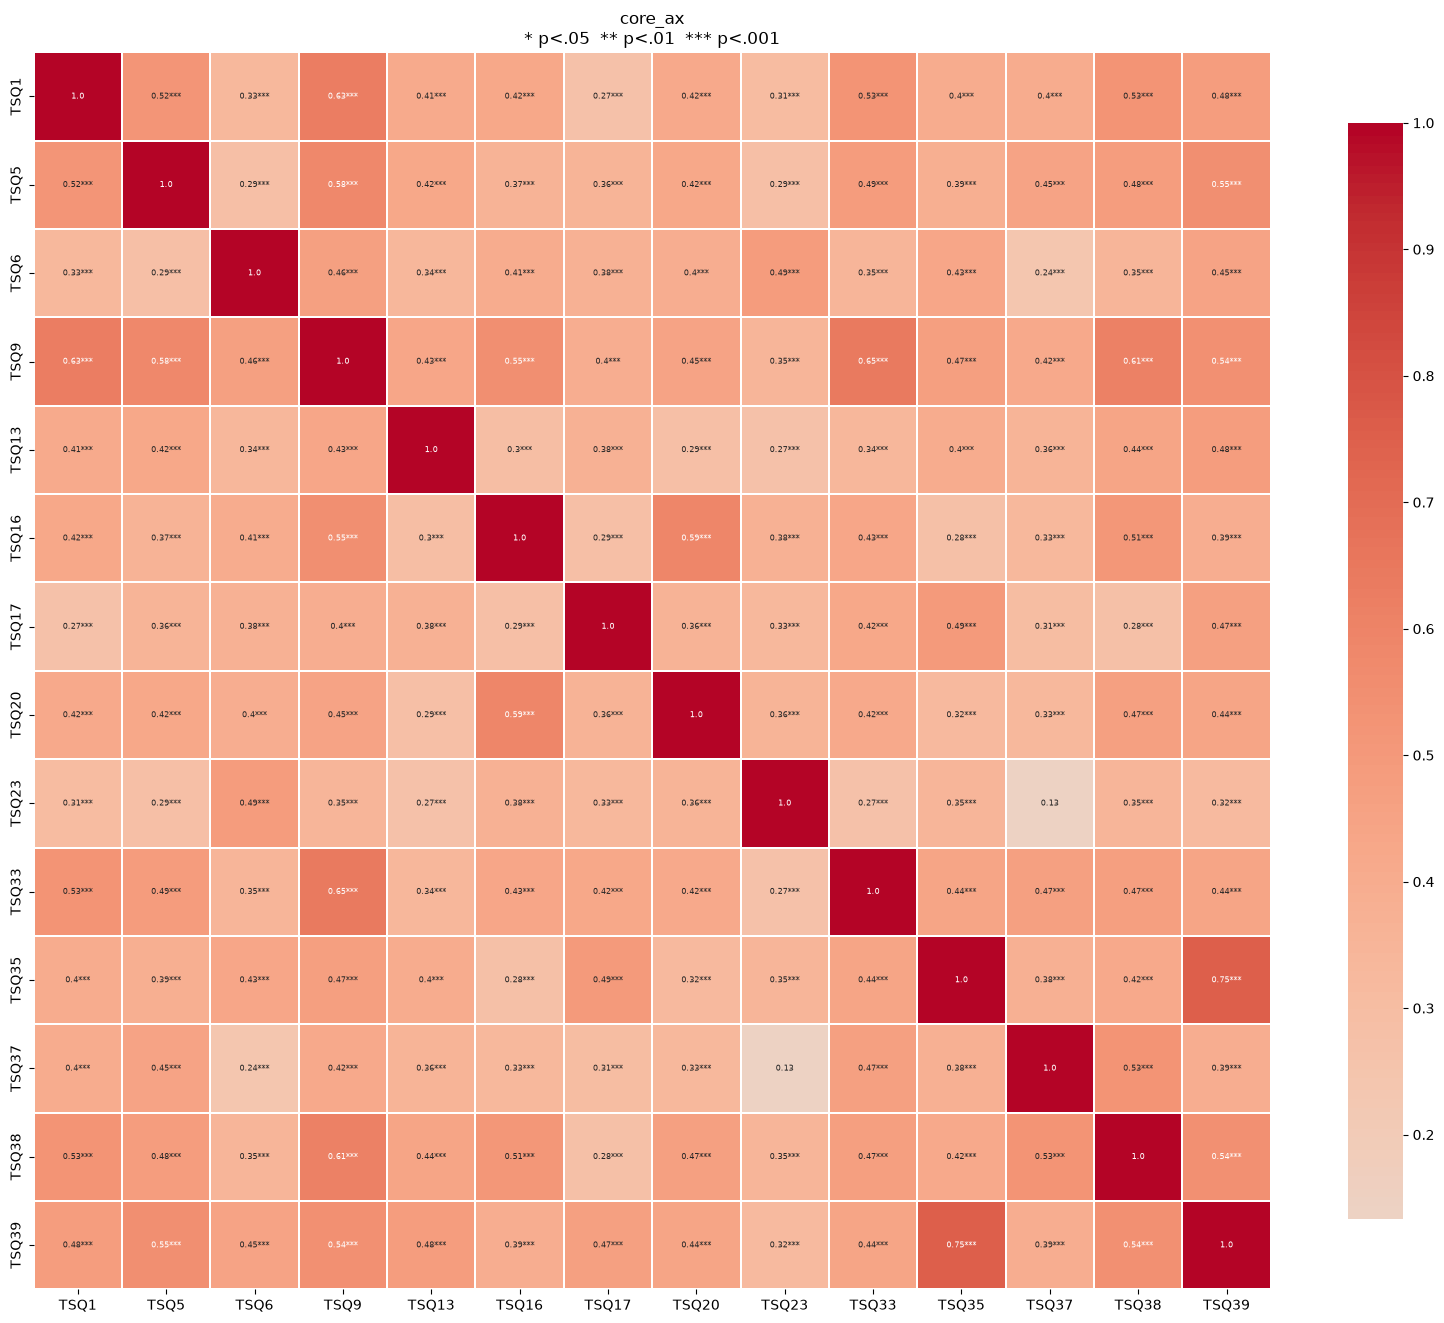

Items à conserver (12/14) : ['TSQ1', 'TSQ5', 'TSQ6', 'TSQ13', 'TSQ16', 'TSQ17', 'TSQ20', 'TSQ23', 'TSQ33', 'TSQ35', 'TSQ37', 'TSQ38']
Items à retirer (2) : ['TSQ9', 'TSQ39']

========================= core_sz =========================


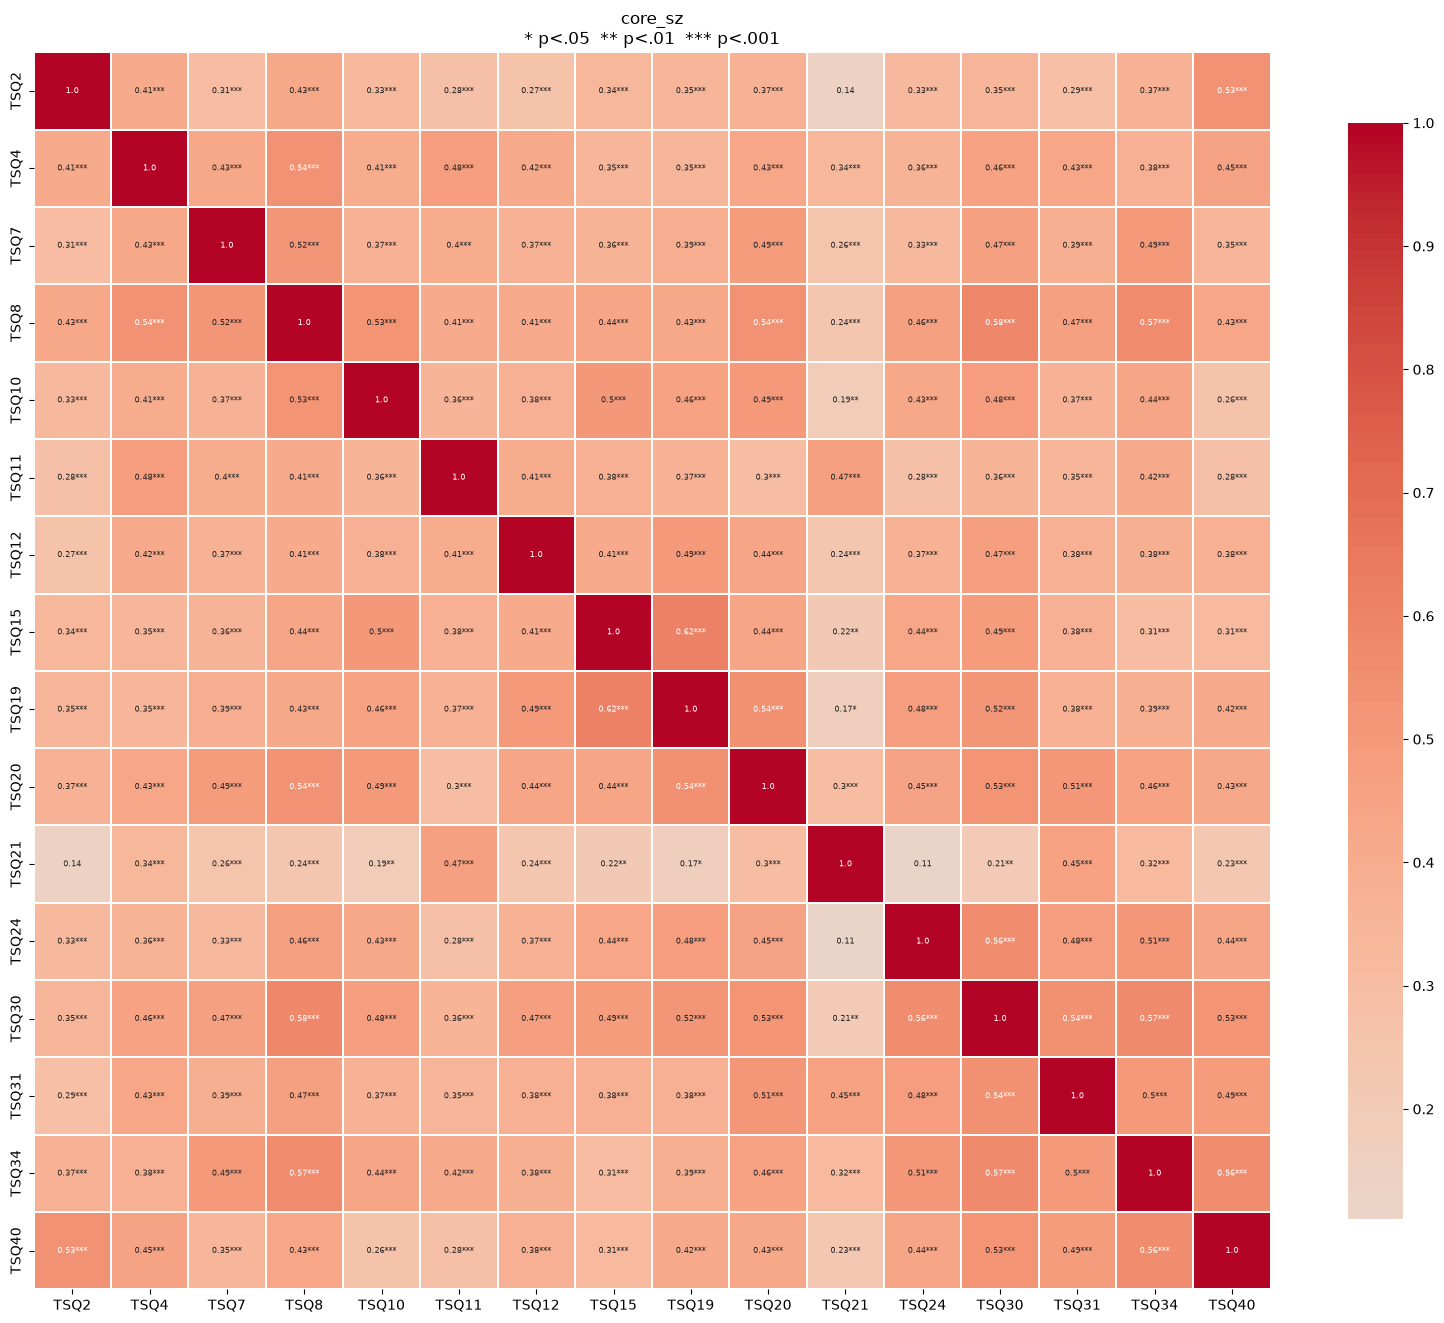

Items à conserver (16/16) : ['TSQ2', 'TSQ4', 'TSQ7', 'TSQ8', 'TSQ10', 'TSQ11', 'TSQ12', 'TSQ15', 'TSQ19', 'TSQ20', 'TSQ21', 'TSQ24', 'TSQ30', 'TSQ31', 'TSQ34', 'TSQ40']
Items à retirer (0) : []

========================= core_mdd =========================


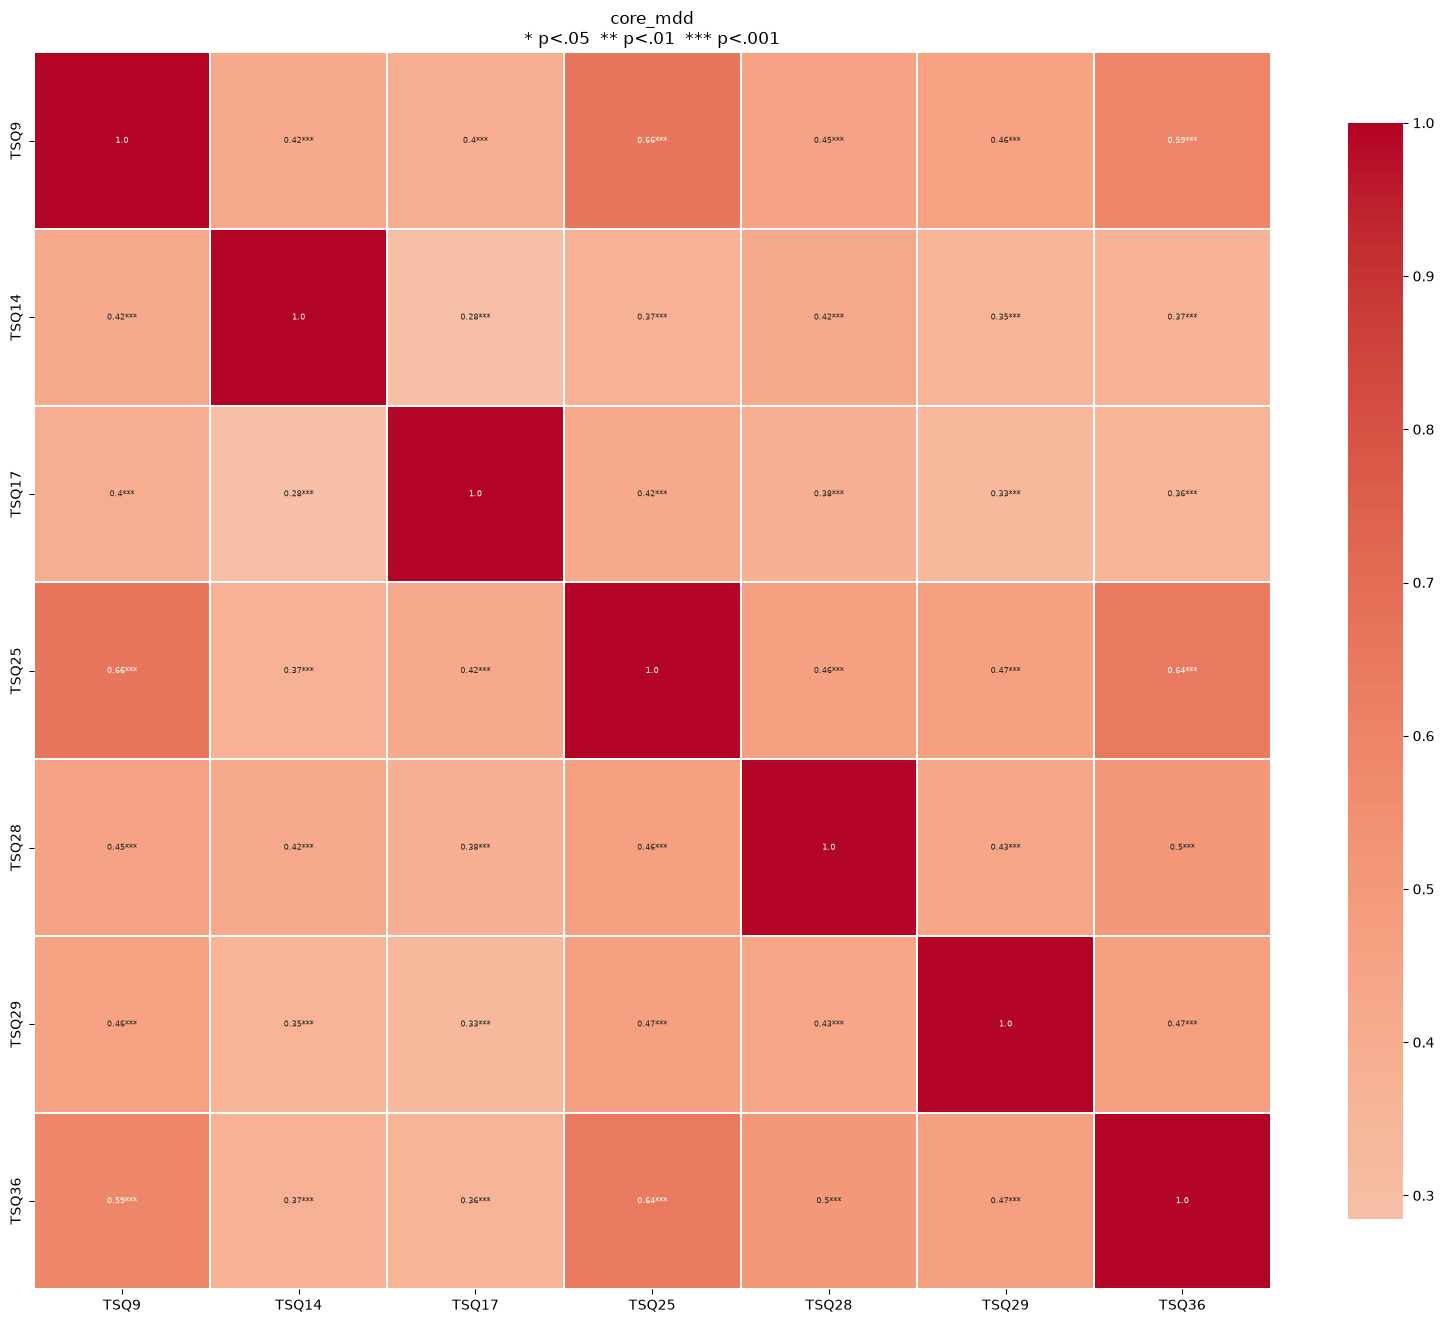

Items à conserver (6/7) : ['TSQ14', 'TSQ17', 'TSQ25', 'TSQ28', 'TSQ29', 'TSQ36']
Items à retirer (1) : ['TSQ9']

========================= core_man =========================


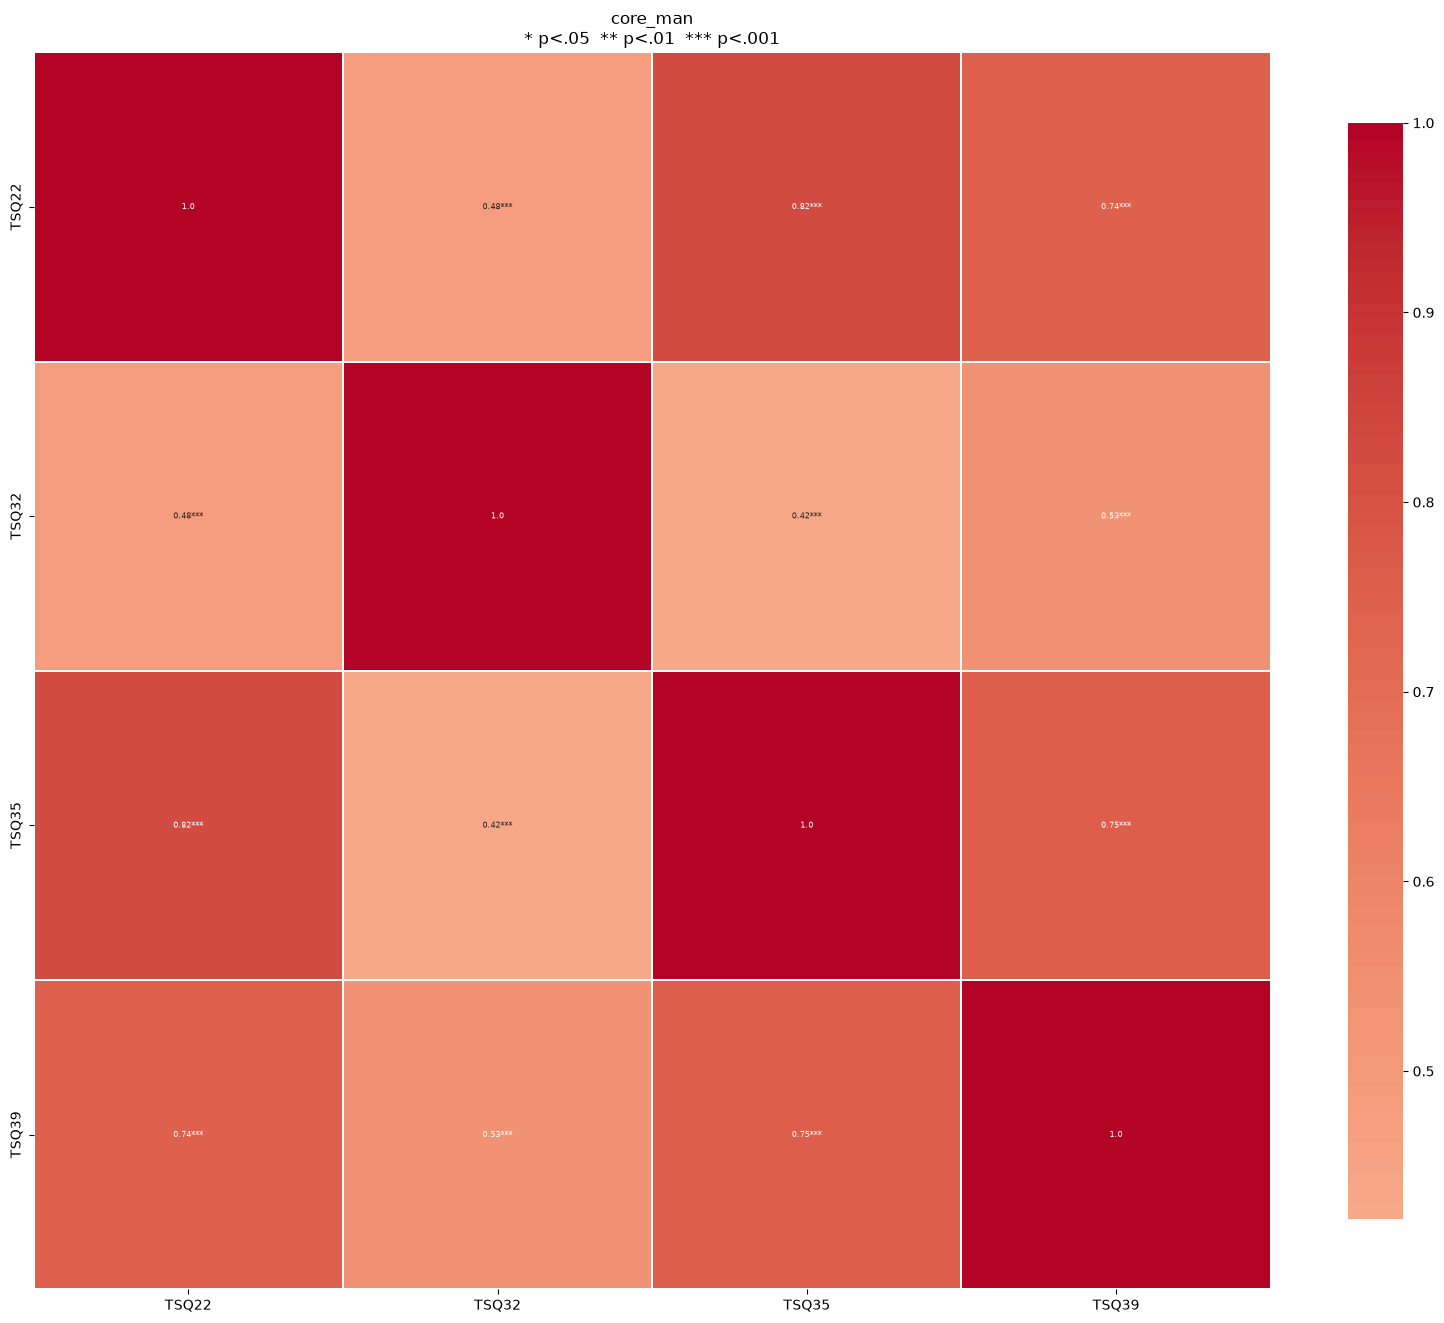

Items à conserver (2/4) : ['TSQ32', 'TSQ35']
Items à retirer (2) : ['TSQ22', 'TSQ39']

========================= core_ptsd =========================


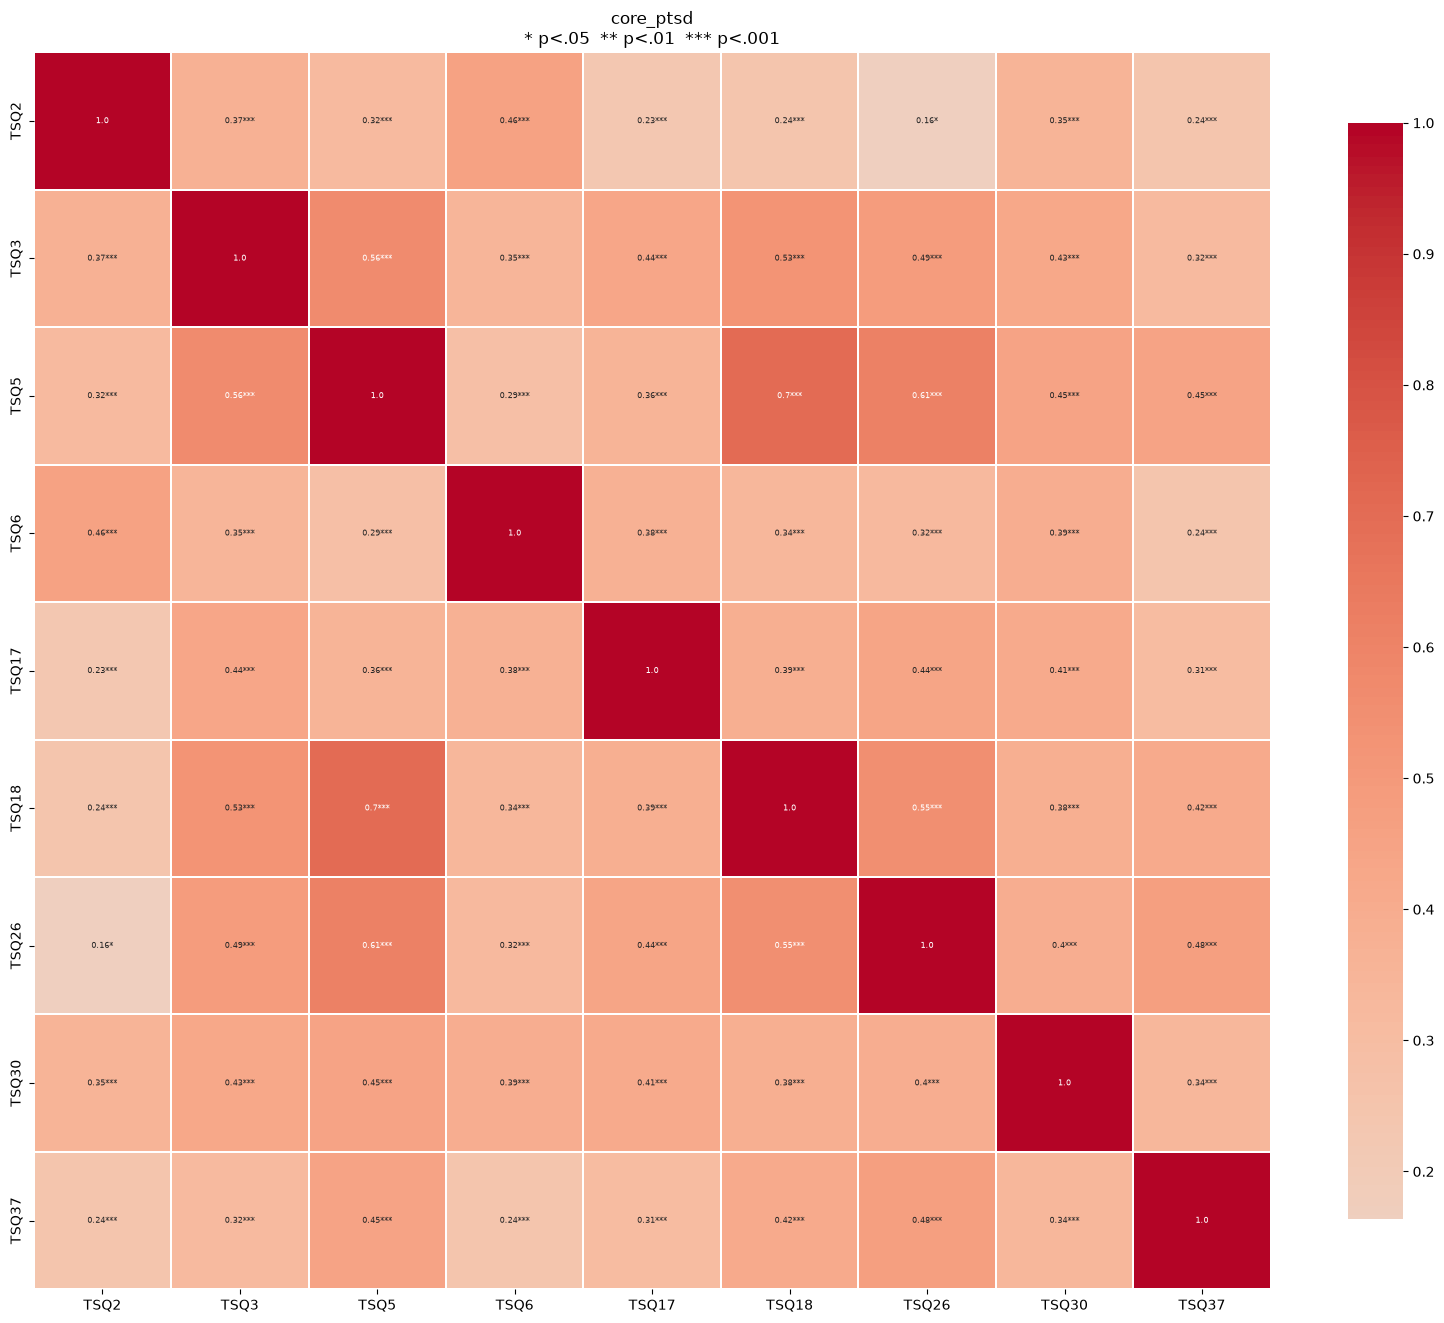

Items à conserver (8/9) : ['TSQ2', 'TSQ3', 'TSQ6', 'TSQ17', 'TSQ18', 'TSQ26', 'TSQ30', 'TSQ37']
Items à retirer (1) : ['TSQ5']

========================= periph_ax =========================


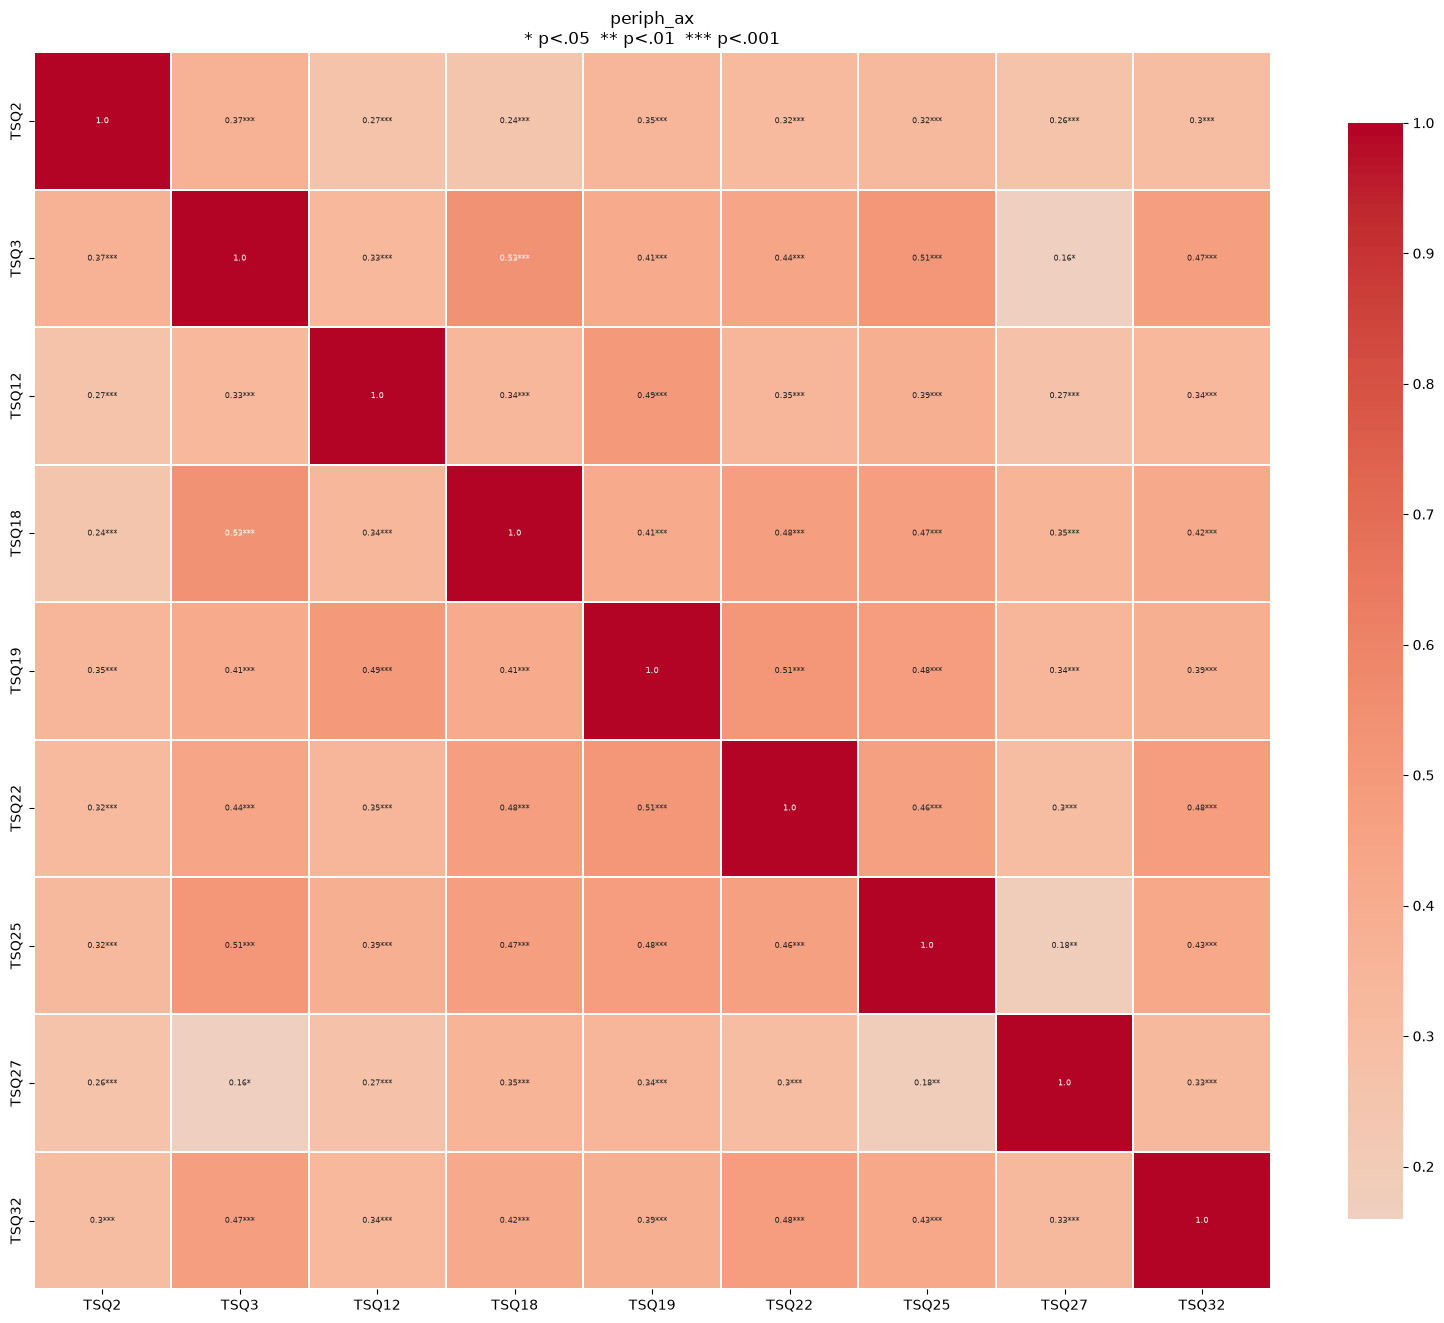

Items à conserver (9/9) : ['TSQ2', 'TSQ3', 'TSQ12', 'TSQ18', 'TSQ19', 'TSQ22', 'TSQ25', 'TSQ27', 'TSQ32']
Items à retirer (0) : []

========================= periph_sz =========================


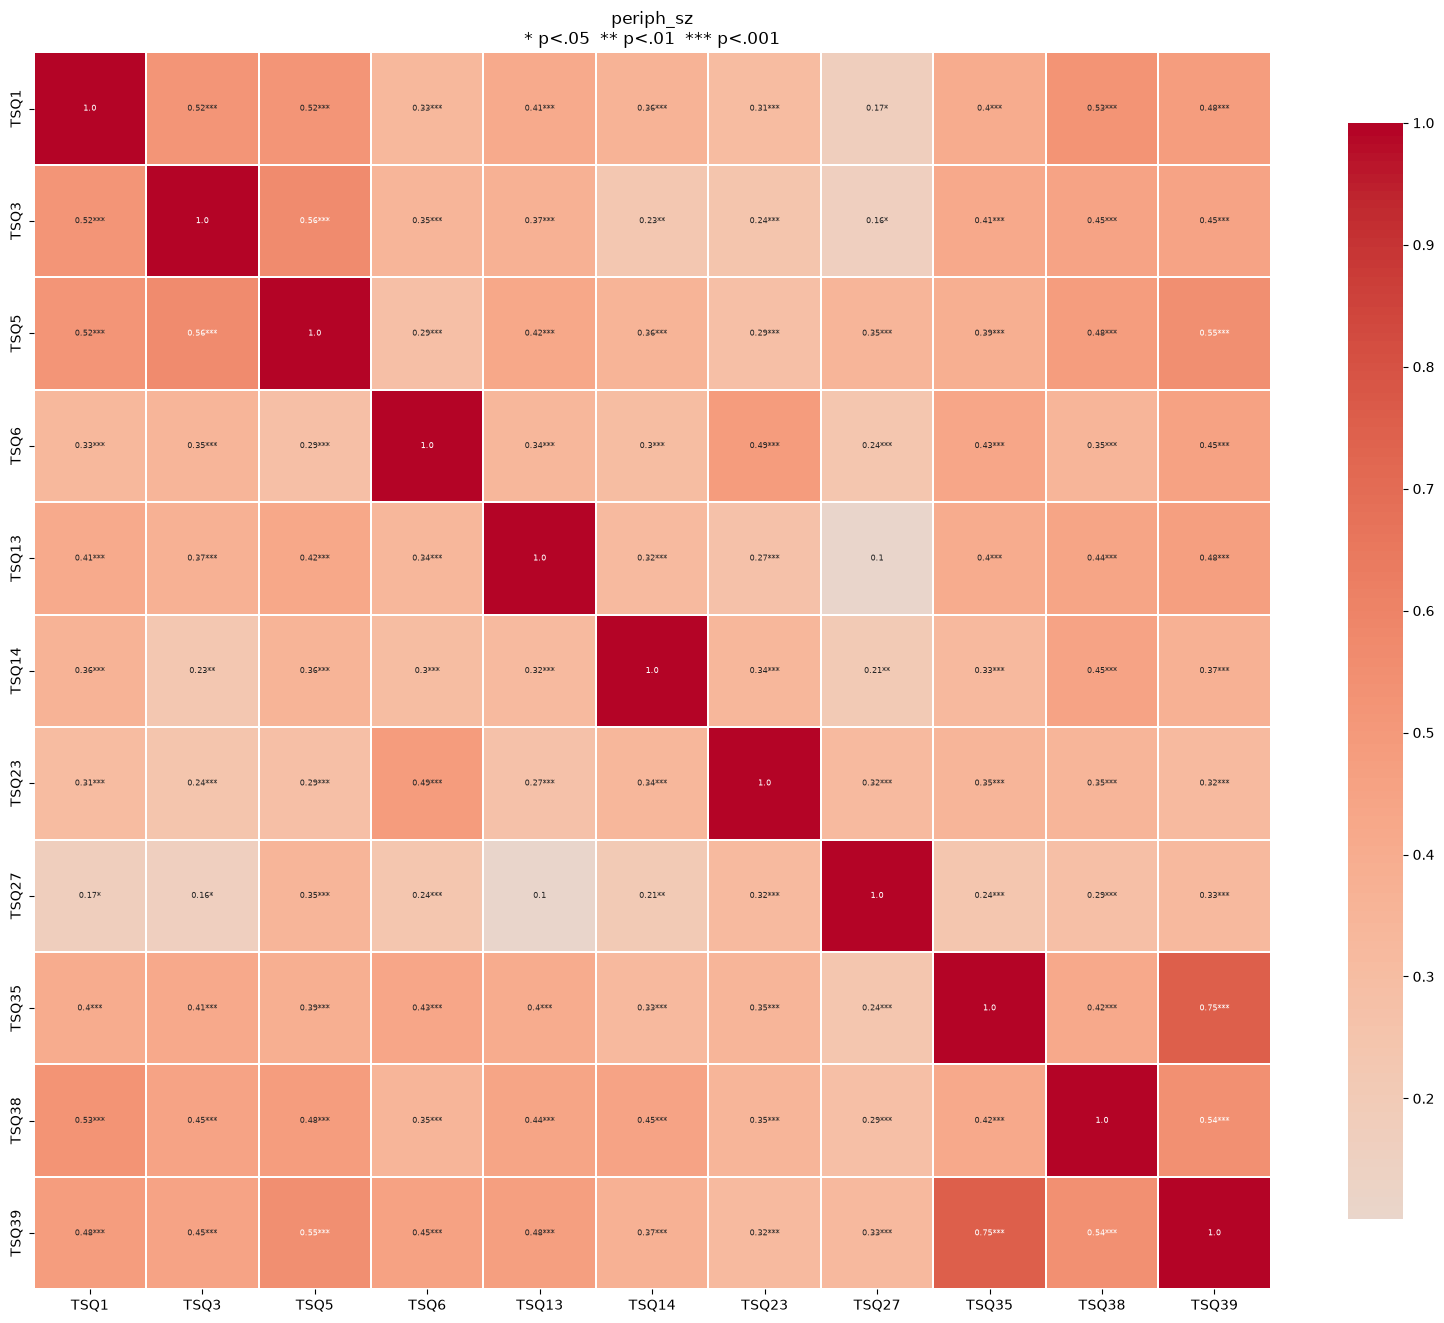

Items à conserver (10/11) : ['TSQ1', 'TSQ3', 'TSQ5', 'TSQ6', 'TSQ13', 'TSQ14', 'TSQ23', 'TSQ27', 'TSQ35', 'TSQ38']
Items à retirer (1) : ['TSQ39']

========================= periph_mdd =========================


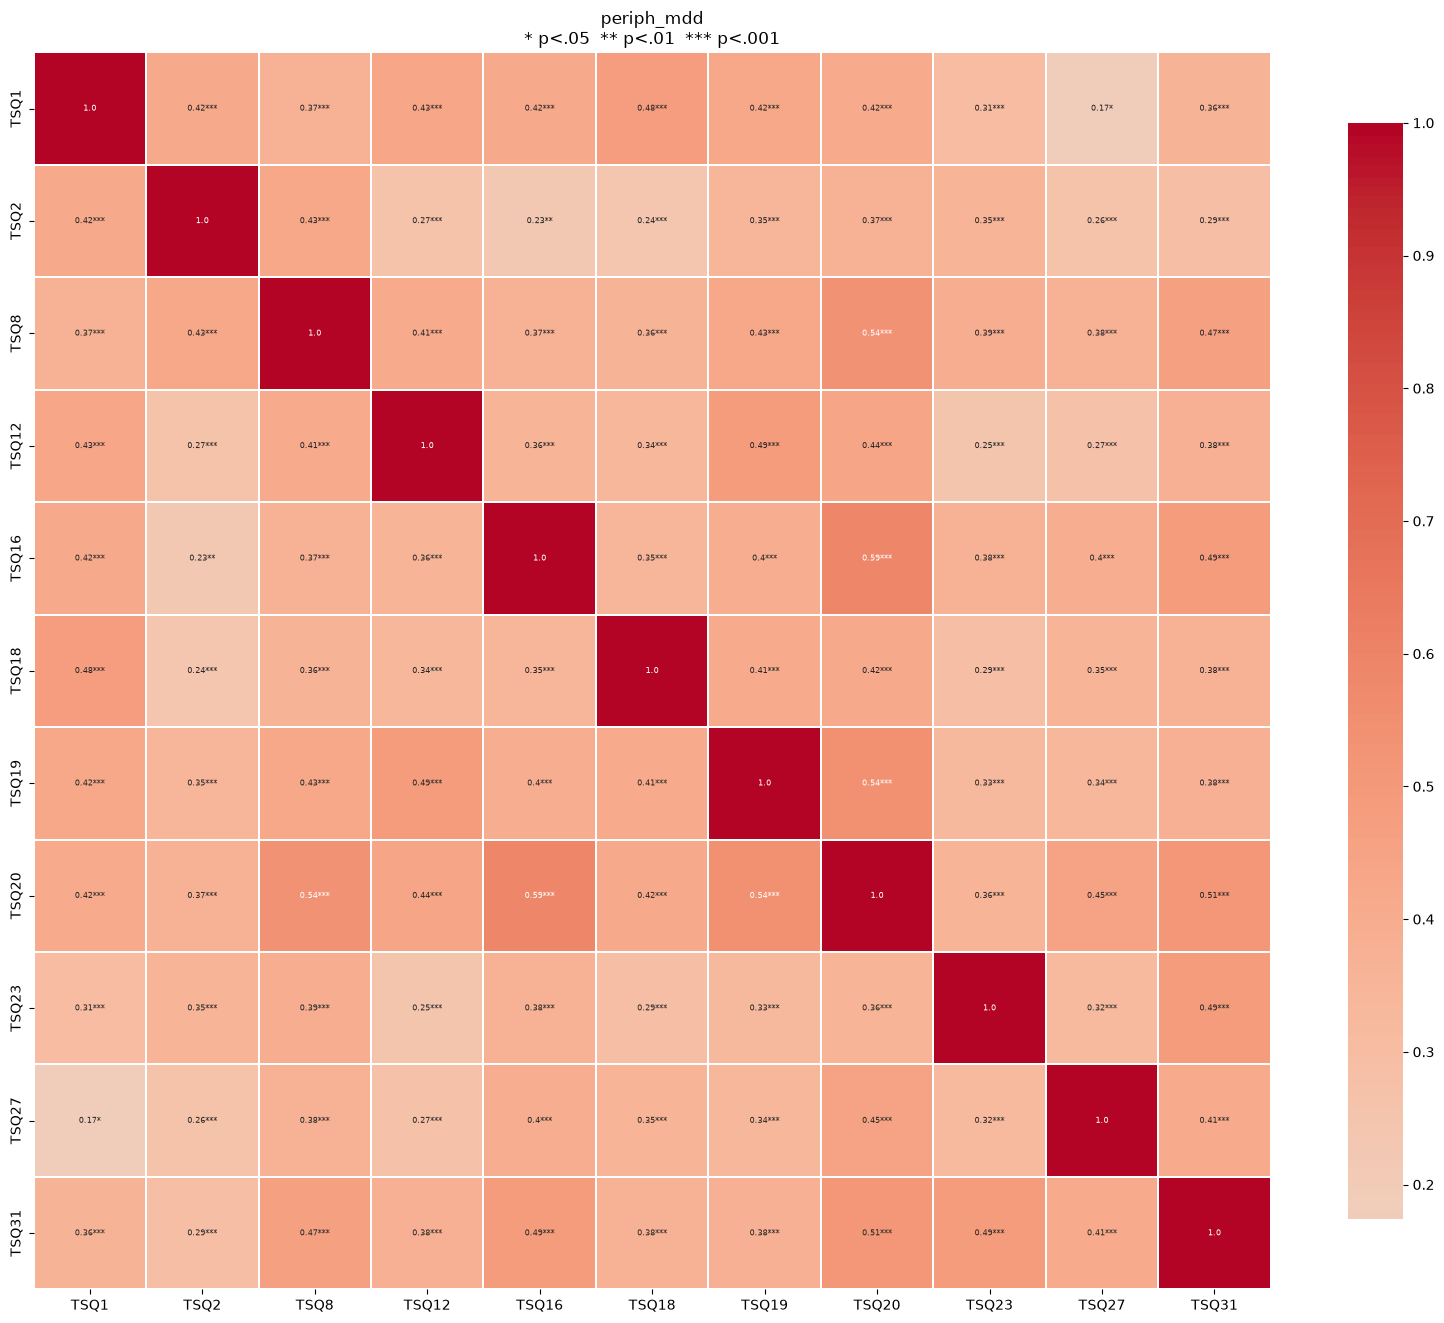

Items à conserver (11/11) : ['TSQ1', 'TSQ2', 'TSQ8', 'TSQ12', 'TSQ16', 'TSQ18', 'TSQ19', 'TSQ20', 'TSQ23', 'TSQ27', 'TSQ31']
Items à retirer (0) : []

========================= periph_man =========================


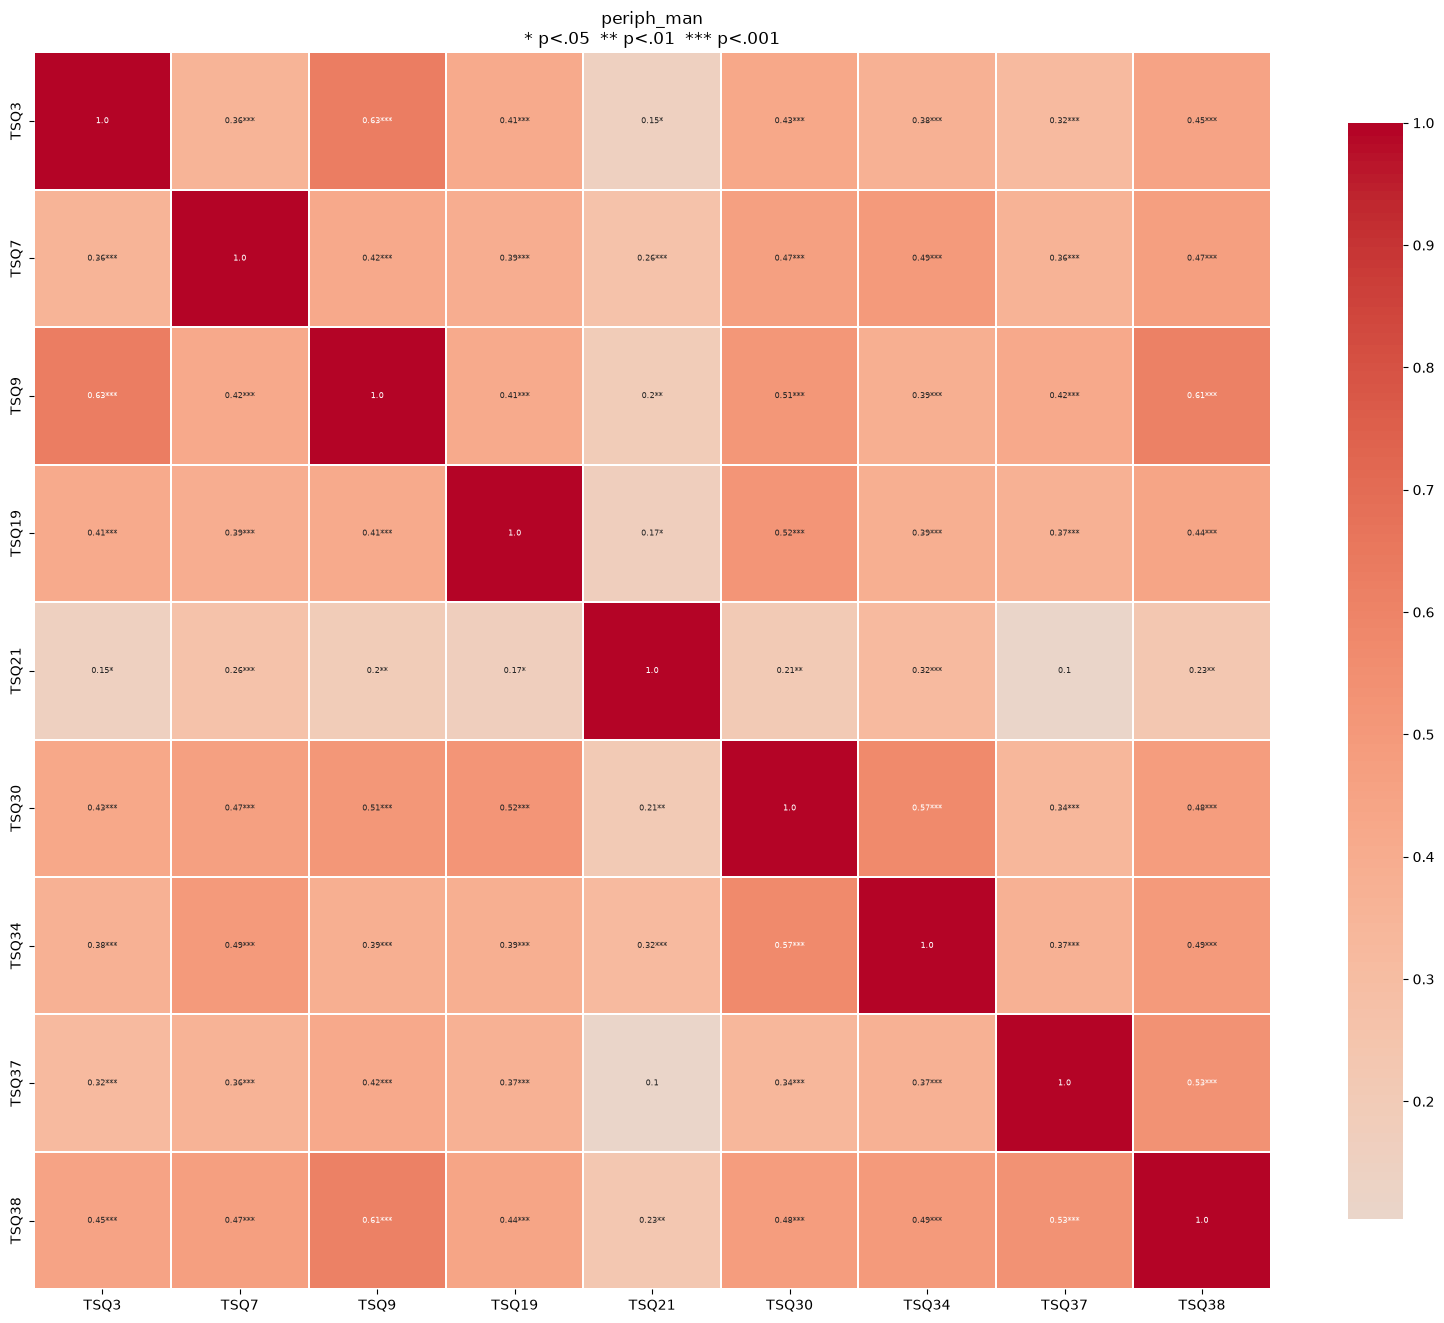

Items à conserver (9/9) : ['TSQ3', 'TSQ7', 'TSQ9', 'TSQ19', 'TSQ21', 'TSQ30', 'TSQ34', 'TSQ37', 'TSQ38']
Items à retirer (0) : []

========================= periph_ptsd =========================


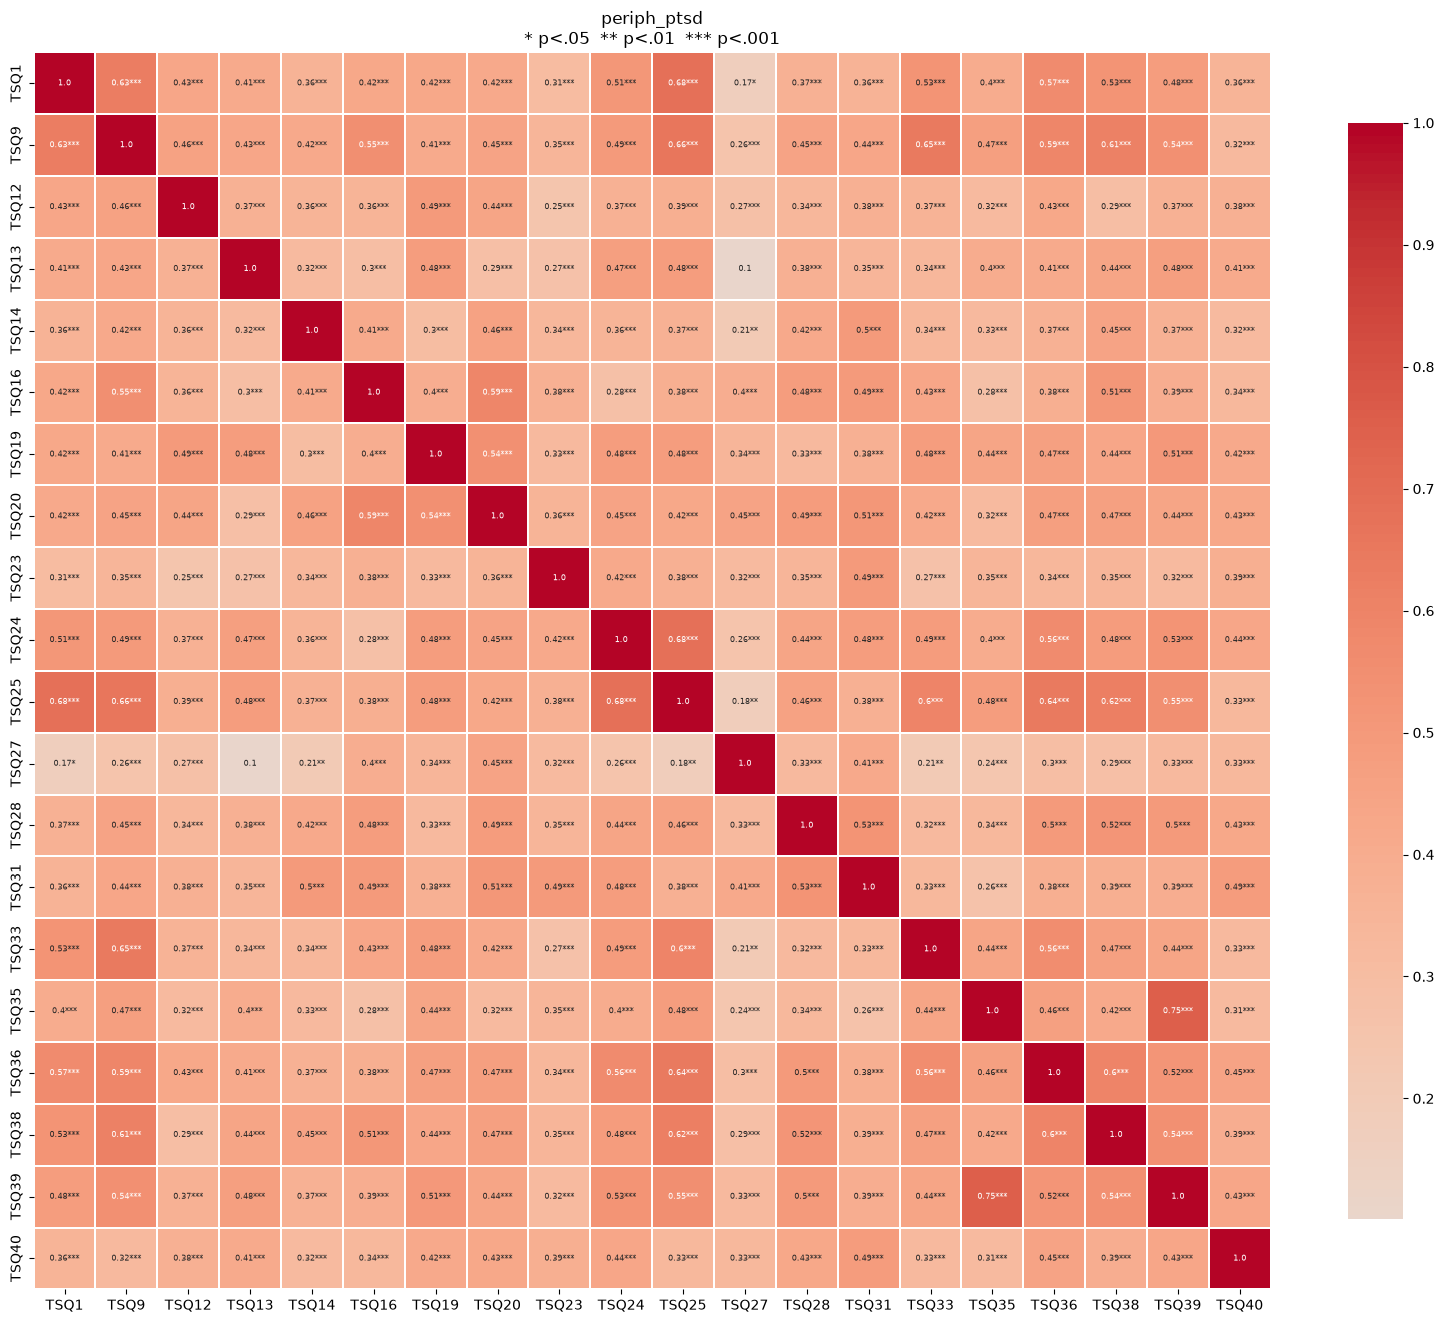

Items à conserver (17/20) : ['TSQ1', 'TSQ12', 'TSQ13', 'TSQ14', 'TSQ16', 'TSQ19', 'TSQ20', 'TSQ23', 'TSQ24', 'TSQ27', 'TSQ28', 'TSQ31', 'TSQ33', 'TSQ35', 'TSQ36', 'TSQ38', 'TSQ40']
Items à retirer (3) : ['TSQ9', 'TSQ25', 'TSQ39']


In [ ]:
from correl_TSQ import compute_tsq_corr, reduce_correlated_features

resultats_corr = {}

for nom, df_subset in sous_echelles.items():
    print(f"\n{'='*25} {nom} {'='*25}")

    items = list(df_subset.columns)

    
    compute_tsq_corr(df_all, items=items, title=nom)

    selected_items = reduce_correlated_features(df_all, items, threshold=0.65)
    dropped_items = [i for i in items if i not in selected_items]

    print(f"Items à conserver ({len(selected_items)}/{len(items)}) :", selected_items)
    print(f"Items à retirer ({len(dropped_items)}) :", dropped_items)

    resultats_corr[nom] = {
        "items_initiaux": items,
        "selected_items": selected_items,
        "dropped_items": dropped_items,
    }

In [16]:
sous_echelles_red = {}
sous_echelles_PD_red = {}

for nom, df_sains in sous_echelles.items():
    dropped = resultats_corr[nom]["dropped_items"] + ["score_total"]

    df_sains_red = df_sains.drop(columns=dropped, errors="ignore")
    df_pd_red = sous_echelles_PD[f"{nom}_PD"].drop(columns=dropped, errors="ignore")

    sous_echelles_red[nom] = df_sains_red
    sous_echelles_PD_red[f"{nom}_PD"] = df_pd_red

    print(f"{nom}: {df_sains.shape[1]} → {df_sains_red.shape[1]} items "
          f"(retirés: {dropped if dropped else 'aucun'})")

core_ax: 14 → 12 items (retirés: ['TSQ9', 'TSQ39', 'score_total'])
core_sz: 16 → 16 items (retirés: ['score_total'])
core_mdd: 7 → 6 items (retirés: ['TSQ9', 'score_total'])
core_man: 4 → 2 items (retirés: ['TSQ22', 'TSQ39', 'score_total'])
core_ptsd: 9 → 8 items (retirés: ['TSQ5', 'score_total'])
periph_ax: 9 → 9 items (retirés: ['score_total'])
periph_sz: 11 → 10 items (retirés: ['TSQ39', 'score_total'])
periph_mdd: 11 → 11 items (retirés: ['score_total'])
periph_man: 9 → 9 items (retirés: ['score_total'])
periph_ptsd: 20 → 17 items (retirés: ['TSQ9', 'TSQ25', 'TSQ39', 'score_total'])


# Boucle sur chaque sous echelle : 
* UMAP sur participants sains +
*  clustering (2 groupes) + 
* train/test sur classifier 
* --> best model à tester sur les participants avec diag --> voir ou sont classés la pop diag concernée par rapport aux sains et aux autres patho

* ex: patients depressifs sont-ils dans le meme cluster/ le + symptomato pour le df core depression? 


=== LogisticRegression ===


c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Li

Meilleurs params : {'clf__C': 0.1, 'clf__penalty': 'l2'}
Meilleur score CV : 0.958 ±  0.038
Score sur test set : 0.962


c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Li

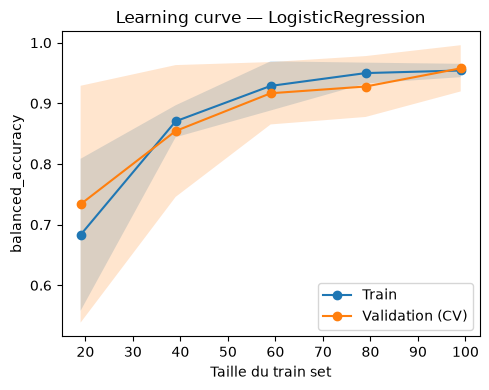


=== SVM_RBF ===


c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


Meilleurs params : {'clf__C': 1, 'clf__gamma': 0.1}
Meilleur score CV : 0.955 ±  0.057
Score sur test set : 0.962


c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1

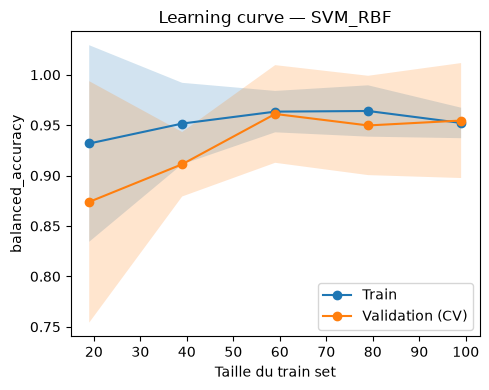


=== RandomForest ===
Meilleurs params : {'clf__max_depth': None, 'clf__min_samples_leaf': 5, 'clf__n_estimators': 100}
Meilleur score CV : 0.955 ±  0.045
Score sur test set : 0.962


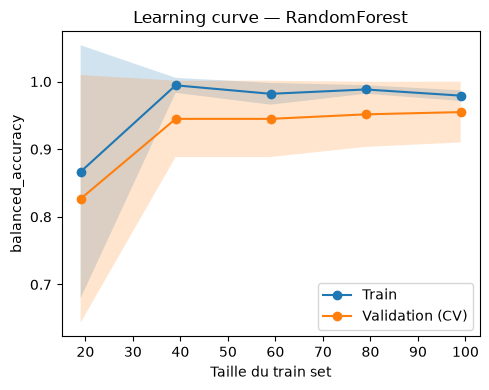


=== HistGradientBoosting ===
Meilleurs params : {'clf__learning_rate': 0.01, 'clf__max_depth': None, 'clf__max_iter': 100}
Meilleur score CV : 0.944 ±  0.039
Score sur test set : 0.962


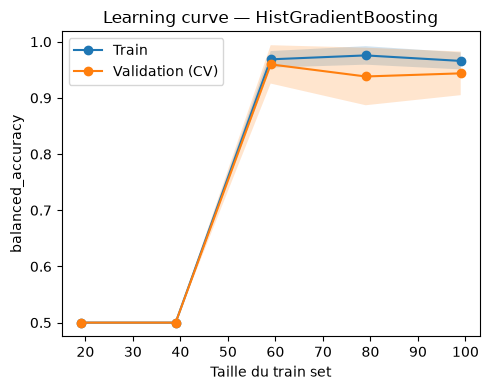


=== Comparaison des modèles ===
                      CV score    CV std  Test score
LogisticRegression    0.957778  0.038103    0.961538
RandomForest          0.954861  0.044898    0.961538
SVM_RBF               0.954583  0.057015    0.961538
HistGradientBoosting  0.943750  0.038814    0.961538

Meilleur modèle : LogisticRegression
              precision    recall  f1-score   support

           0       1.00      0.92      0.96        26
           1       0.89      1.00      0.94        16

    accuracy                           0.95        42
   macro avg       0.94      0.96      0.95        42
weighted avg       0.96      0.95      0.95        42



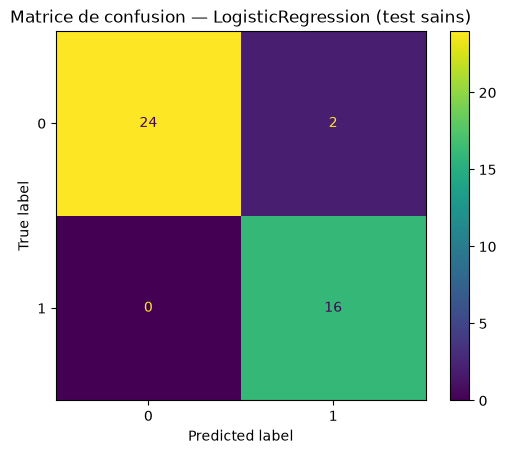

In [ ]:
results, summary, best_model_name, best_model = train_and_compare_classifiers(
    X_train, y_train, X_test, y_test, scoring="balanced_accuracy"
)


========================= core_ax =========================


c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


cluster
0    73
1    93
Name: count, dtype: int64
Cluster 0: 73 participants (group 0: 73)
Cluster 1: 93 participants (group 0: 93)

=== LogisticRegression ===
Meilleurs params : {'clf__C': 10, 'clf__penalty': 'l2'}
Meilleur score CV : 0.929 ±  0.038
Score sur test set : 0.868


c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Li

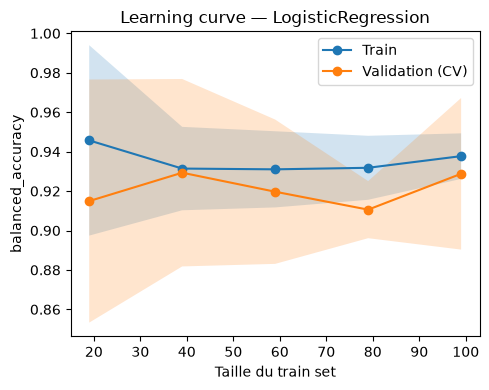


=== SVM_RBF ===


c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1

Meilleurs params : {'clf__C': 10, 'clf__gamma': 'scale'}
Meilleur score CV : 0.951 ±  0.03
Score sur test set : 0.854


c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1

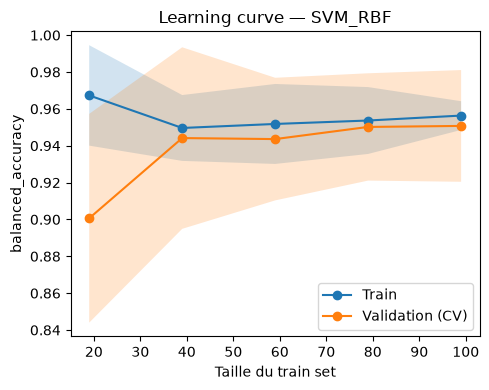


=== RandomForest ===
Meilleurs params : {'clf__max_depth': None, 'clf__min_samples_leaf': 5, 'clf__n_estimators': 100}
Meilleur score CV : 0.942 ±  0.043
Score sur test set : 0.847


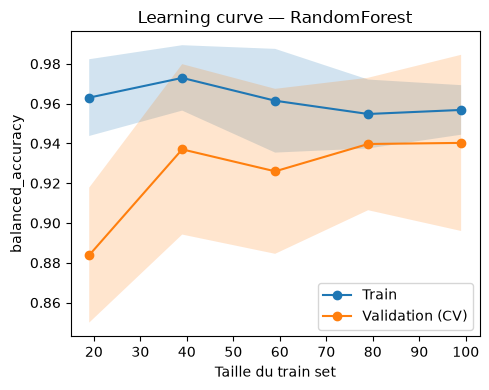


=== HistGradientBoosting ===
Meilleurs params : {'clf__learning_rate': 0.05, 'clf__max_depth': None, 'clf__max_iter': 200}
Meilleur score CV : 0.942 ±  0.043
Score sur test set : 0.854


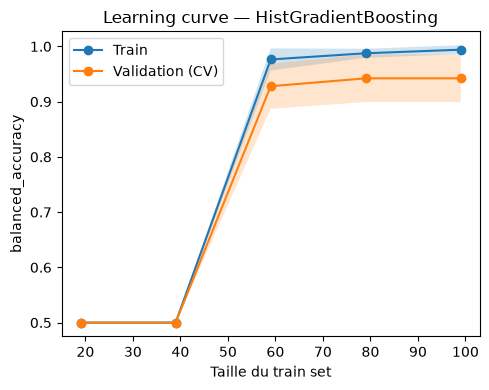


=== Comparaison des modèles ===
                      CV score    CV std  Test score
SVM_RBF               0.950749  0.030312    0.854167
RandomForest          0.942208  0.043044    0.847222
HistGradientBoosting  0.942208  0.043044    0.854167
LogisticRegression    0.928771  0.038439    0.868056

Meilleur modèle : SVM_RBF
              precision    recall  f1-score   support

           0       0.83      0.83      0.83        18
           1       0.88      0.88      0.88        24

    accuracy                           0.86        42
   macro avg       0.85      0.85      0.85        42
weighted avg       0.86      0.86      0.86        42



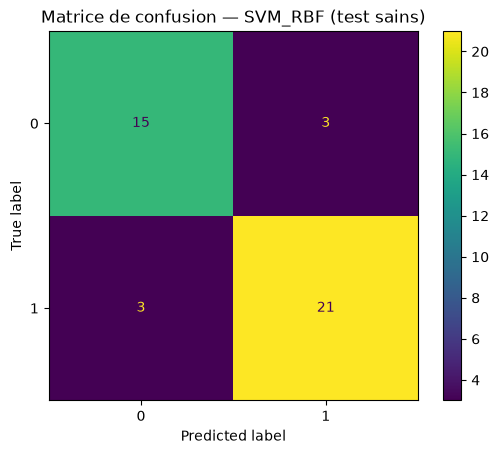

Meilleur modèle pour core_ax : SVM_RBF

========================= core_sz =========================


c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


cluster
0    111
1     55
Name: count, dtype: int64
Cluster 0: 111 participants (group 0: 111)
Cluster 1: 55 participants (group 0: 55)

=== LogisticRegression ===


c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Li

Meilleurs params : {'clf__C': 10, 'clf__penalty': 'l2'}
Meilleur score CV : 0.909 ±  0.052
Score sur test set : 0.964


c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Li

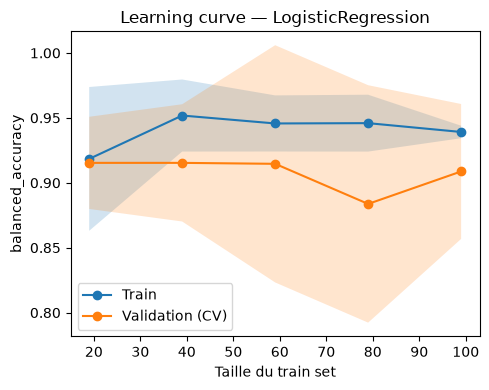


=== SVM_RBF ===


c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1

Meilleurs params : {'clf__C': 10, 'clf__gamma': 1}
Meilleur score CV : 0.946 ±  0.03
Score sur test set : 0.964


c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1

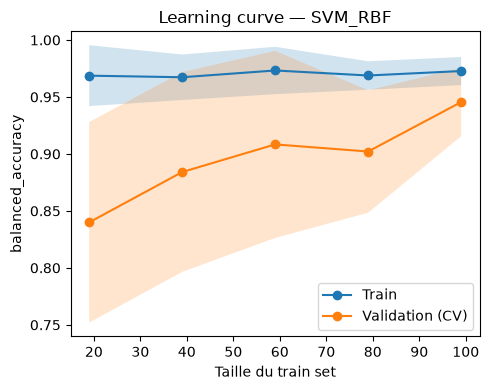


=== RandomForest ===
Meilleurs params : {'clf__max_depth': None, 'clf__min_samples_leaf': 5, 'clf__n_estimators': 100}
Meilleur score CV : 0.954 ±  0.038
Score sur test set : 0.946


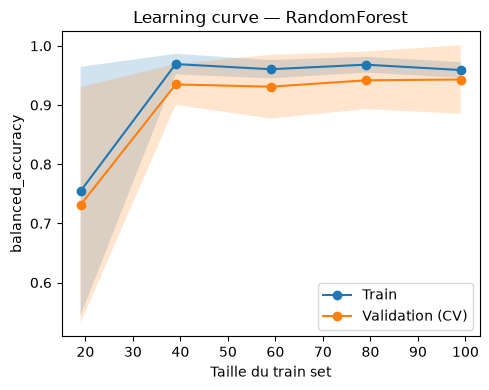


=== HistGradientBoosting ===
Meilleurs params : {'clf__learning_rate': 0.01, 'clf__max_depth': None, 'clf__max_iter': 400}
Meilleur score CV : 0.941 ±  0.018
Score sur test set : 0.964


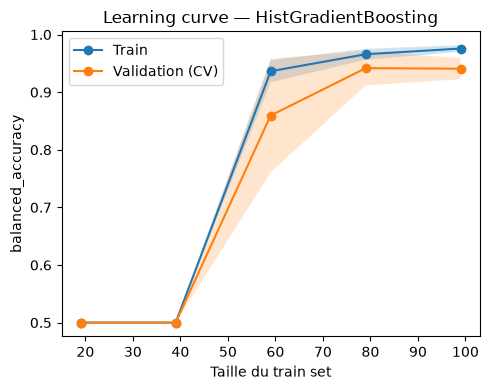


=== Comparaison des modèles ===
                      CV score    CV std  Test score
RandomForest          0.954248  0.037603    0.946429
SVM_RBF               0.945507  0.029997    0.964286
HistGradientBoosting  0.940727  0.018224    0.964286
LogisticRegression    0.908742  0.051952    0.964286

Meilleur modèle : RandomForest
              precision    recall  f1-score   support

           0       1.00      0.89      0.94        28
           1       0.82      1.00      0.90        14

    accuracy                           0.93        42
   macro avg       0.91      0.95      0.92        42
weighted avg       0.94      0.93      0.93        42



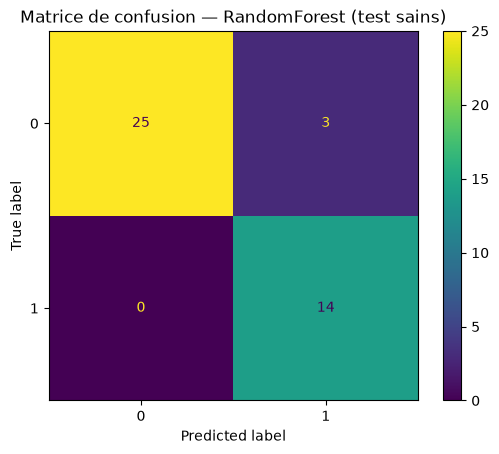

Meilleur modèle pour core_sz : RandomForest

========================= core_mdd =========================


c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


cluster
0    109
1     57
Name: count, dtype: int64
Cluster 0: 109 participants (group 0: 109)
Cluster 1: 57 participants (group 0: 57)

=== LogisticRegression ===
Meilleurs params : {'clf__C': 10, 'clf__penalty': 'l2'}
Meilleur score CV : 0.936 ±  0.033
Score sur test set : 0.821


c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Li

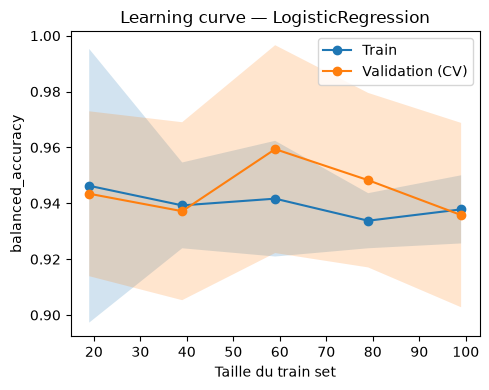


=== SVM_RBF ===


c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1

Meilleurs params : {'clf__C': 10, 'clf__gamma': 1}
Meilleur score CV : 0.971 ±  0.018
Score sur test set : 0.821


c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1

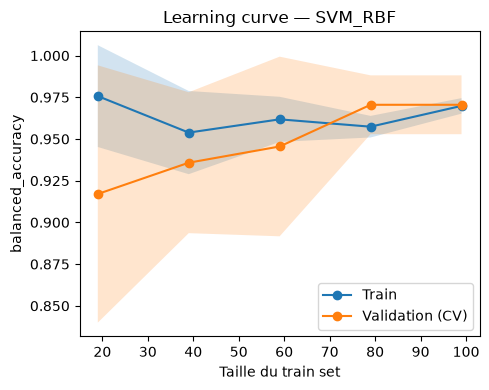


=== RandomForest ===
Meilleurs params : {'clf__max_depth': 3, 'clf__min_samples_leaf': 5, 'clf__n_estimators': 100}
Meilleur score CV : 0.948 ±  0.021
Score sur test set : 0.821


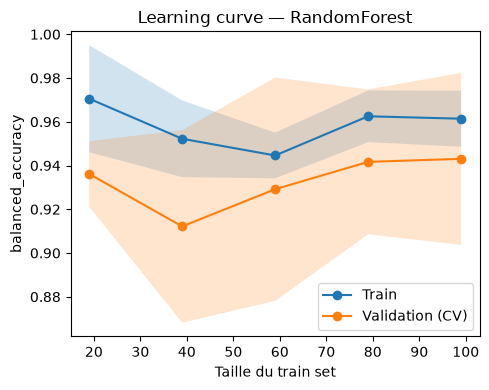


=== HistGradientBoosting ===
Meilleurs params : {'clf__learning_rate': 0.05, 'clf__max_depth': None, 'clf__max_iter': 100}
Meilleur score CV : 0.965 ±  0.033
Score sur test set : 0.786


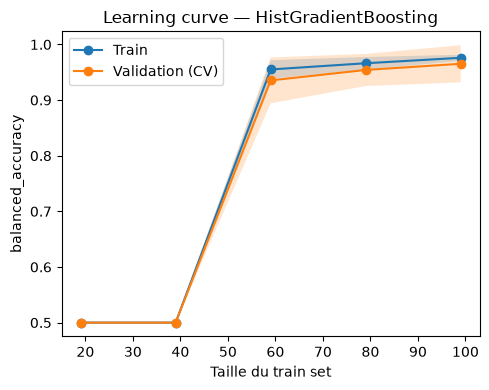


=== Comparaison des modèles ===
                      CV score    CV std  Test score
SVM_RBF               0.970507  0.017637    0.821429
HistGradientBoosting  0.965278  0.033377    0.785714
RandomForest          0.948284  0.020867    0.821429
LogisticRegression    0.935784  0.032998    0.821429

Meilleur modèle : SVM_RBF
              precision    recall  f1-score   support

           0       0.87      0.93      0.90        28
           1       0.83      0.71      0.77        14

    accuracy                           0.86        42
   macro avg       0.85      0.82      0.83        42
weighted avg       0.86      0.86      0.85        42



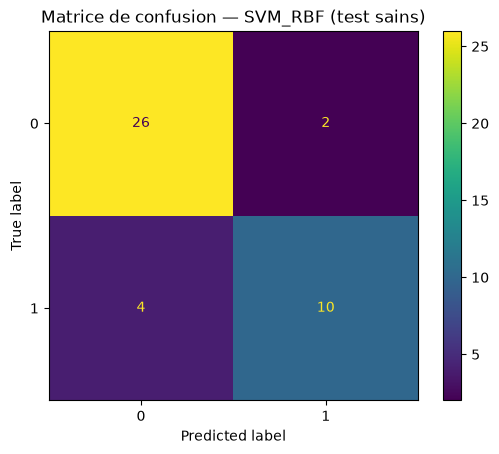

Meilleur modèle pour core_mdd : SVM_RBF

========================= core_man =========================


c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


cluster
0    79
1    87
Name: count, dtype: int64
Cluster 0: 79 participants (group 0: 79)
Cluster 1: 87 participants (group 0: 87)

=== LogisticRegression ===
Meilleurs params : {'clf__C': 0.01, 'clf__penalty': 'l2'}
Meilleur score CV : 0.977 ±  0.031
Score sur test set : 0.955


c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Li

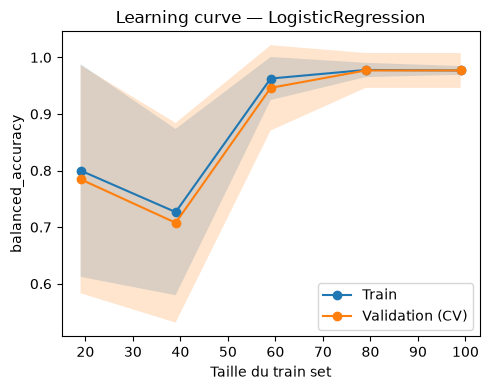


=== SVM_RBF ===


c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1

Meilleurs params : {'clf__C': 100, 'clf__gamma': 1}
Meilleur score CV : 0.985 ±  0.031
Score sur test set : 0.975


c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1

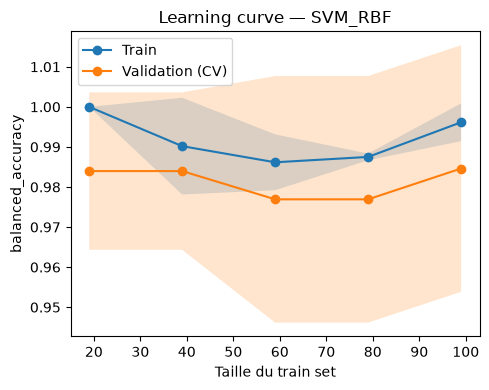


=== RandomForest ===
Meilleurs params : {'clf__max_depth': None, 'clf__min_samples_leaf': 5, 'clf__n_estimators': 100}
Meilleur score CV : 1.0 ±  0.0
Score sur test set : 0.975


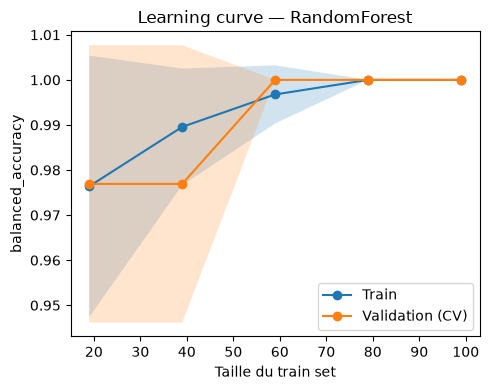


=== HistGradientBoosting ===
Meilleurs params : {'clf__learning_rate': 0.01, 'clf__max_depth': None, 'clf__max_iter': 100}
Meilleur score CV : 1.0 ±  0.0
Score sur test set : 0.975


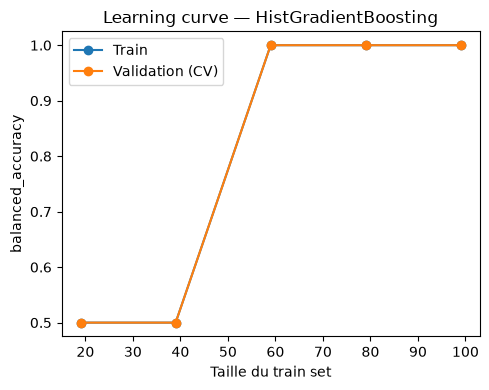


=== Comparaison des modèles ===
                      CV score    CV std  Test score
HistGradientBoosting  1.000000  0.000000    0.975000
RandomForest          1.000000  0.000000    0.975000
SVM_RBF               0.984615  0.030769    0.975000
LogisticRegression    0.976923  0.030769    0.954545

Meilleur modèle : HistGradientBoosting
              precision    recall  f1-score   support

           0       1.00      0.95      0.97        20
           1       0.96      1.00      0.98        22

    accuracy                           0.98        42
   macro avg       0.98      0.97      0.98        42
weighted avg       0.98      0.98      0.98        42



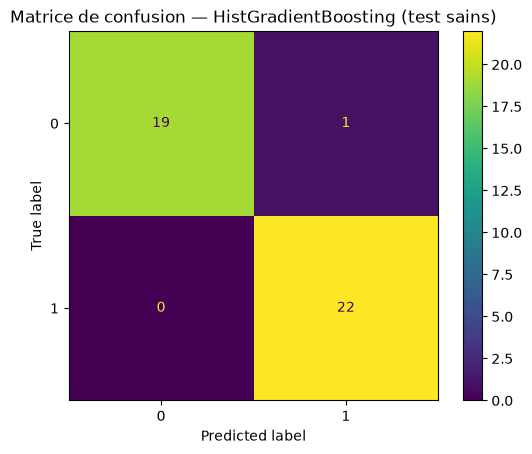

Meilleur modèle pour core_man : HistGradientBoosting

========================= core_ptsd =========================


c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


cluster
0     66
1    100
Name: count, dtype: int64
Cluster 0: 66 participants (group 0: 66)
Cluster 1: 100 participants (group 0: 100)

=== LogisticRegression ===
Meilleurs params : {'clf__C': 1, 'clf__penalty': 'l2'}
Meilleur score CV : 0.977 ±  0.033
Score sur test set : 0.971


c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Li

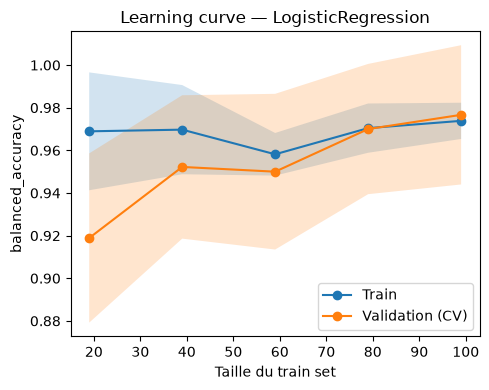


=== SVM_RBF ===


c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1

Meilleurs params : {'clf__C': 1, 'clf__gamma': 0.1}
Meilleur score CV : 0.977 ±  0.033
Score sur test set : 0.971


c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1

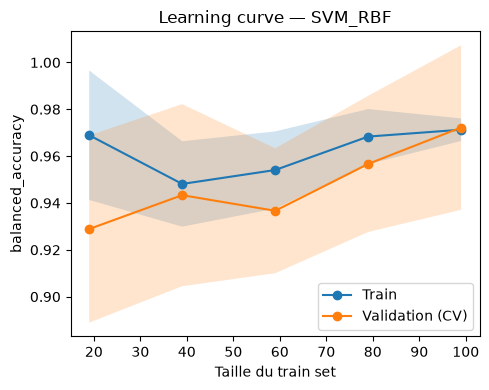


=== RandomForest ===
Meilleurs params : {'clf__max_depth': None, 'clf__min_samples_leaf': 5, 'clf__n_estimators': 100}
Meilleur score CV : 0.967 ±  0.018
Score sur test set : 0.971


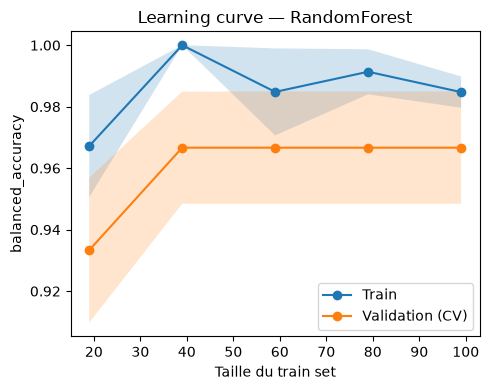


=== HistGradientBoosting ===
Meilleurs params : {'clf__learning_rate': 0.05, 'clf__max_depth': None, 'clf__max_iter': 400}
Meilleur score CV : 0.98 ±  0.024
Score sur test set : 0.971


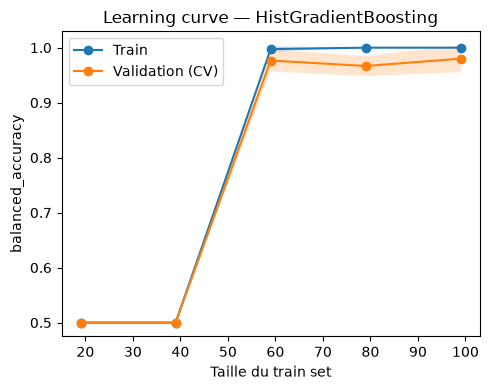


=== Comparaison des modèles ===
                      CV score    CV std  Test score
HistGradientBoosting  0.980000  0.024495    0.970588
LogisticRegression    0.976667  0.032660    0.970588
SVM_RBF               0.976667  0.032660    0.970588
RandomForest          0.966667  0.018257    0.970588

Meilleur modèle : HistGradientBoosting
              precision    recall  f1-score   support

           0       1.00      0.94      0.97        17
           1       0.96      1.00      0.98        25

    accuracy                           0.98        42
   macro avg       0.98      0.97      0.98        42
weighted avg       0.98      0.98      0.98        42



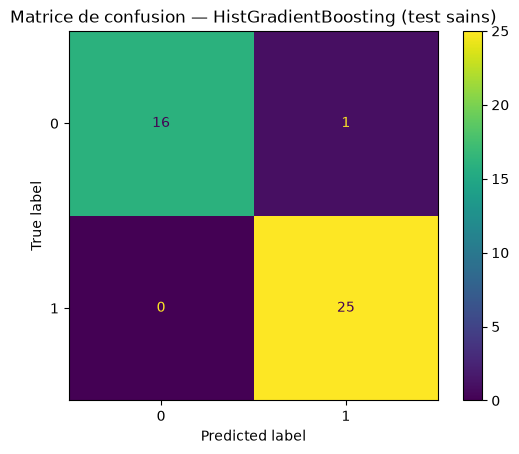

Meilleur modèle pour core_ptsd : HistGradientBoosting

========================= periph_ax =========================


c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


cluster
0     65
1    101
Name: count, dtype: int64
Cluster 0: 65 participants (group 0: 65)
Cluster 1: 101 participants (group 0: 101)

=== LogisticRegression ===
Meilleurs params : {'clf__C': 1, 'clf__penalty': 'l2'}
Meilleur score CV : 0.944 ±  0.072
Score sur test set : 0.942


c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Li

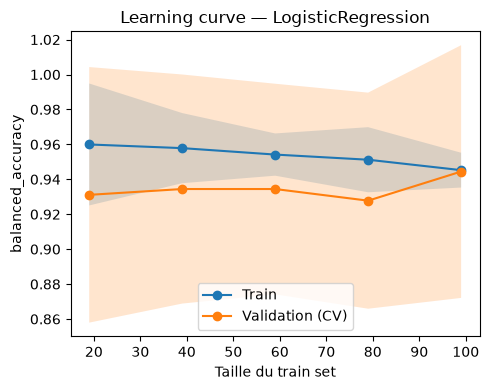


=== SVM_RBF ===


c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1

Meilleurs params : {'clf__C': 100, 'clf__gamma': 1}
Meilleur score CV : 0.952 ±  0.059
Score sur test set : 0.892


c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1

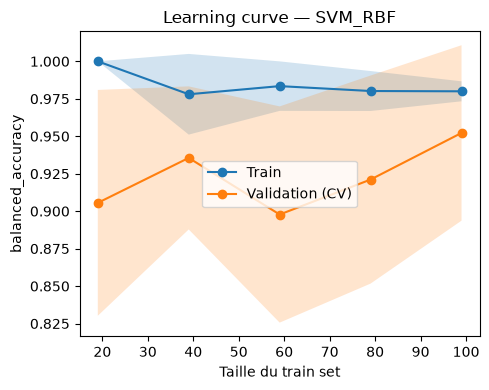


=== RandomForest ===
Meilleurs params : {'clf__max_depth': None, 'clf__min_samples_leaf': 5, 'clf__n_estimators': 100}
Meilleur score CV : 0.928 ±  0.052
Score sur test set : 0.93


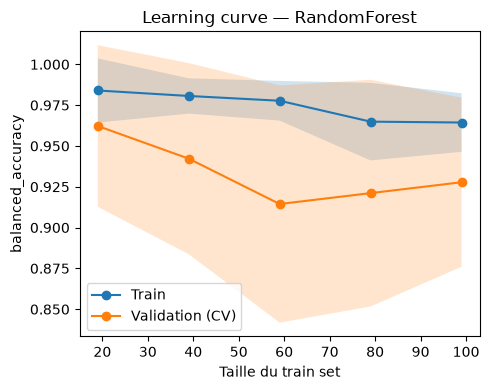


=== HistGradientBoosting ===
Meilleurs params : {'clf__learning_rate': 0.01, 'clf__max_depth': None, 'clf__max_iter': 400}
Meilleur score CV : 0.951 ±  0.062
Score sur test set : 0.93


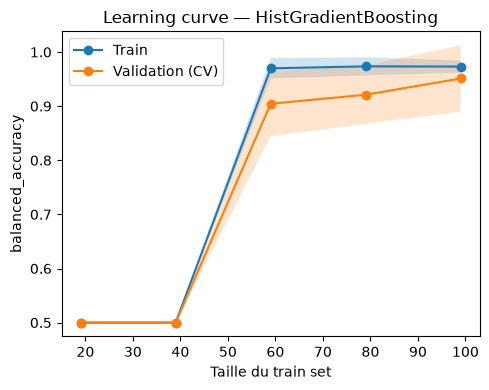


=== Comparaison des modèles ===
                      CV score    CV std  Test score
SVM_RBF               0.952222  0.058542    0.891827
HistGradientBoosting  0.951111  0.061504    0.930288
LogisticRegression    0.944444  0.072350    0.942308
RandomForest          0.927778  0.051759    0.930288

Meilleur modèle : SVM_RBF
              precision    recall  f1-score   support

           0       0.79      0.94      0.86        16
           1       0.96      0.85      0.90        26

    accuracy                           0.88        42
   macro avg       0.87      0.89      0.88        42
weighted avg       0.89      0.88      0.88        42



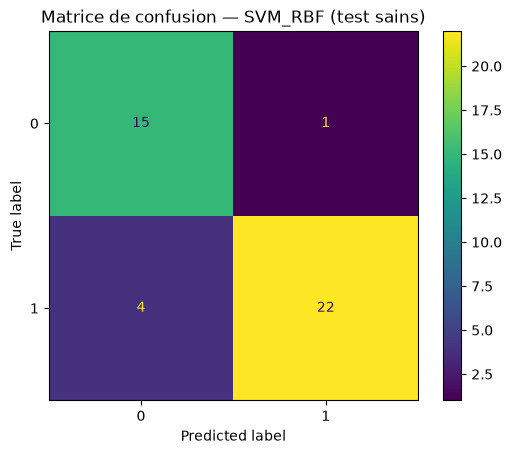

Meilleur modèle pour periph_ax : SVM_RBF

========================= periph_sz =========================


c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


cluster
0    97
1    69
Name: count, dtype: int64
Cluster 0: 97 participants (group 0: 97)
Cluster 1: 69 participants (group 0: 69)

=== LogisticRegression ===
Meilleurs params : {'clf__C': 100, 'clf__penalty': 'l2'}
Meilleur score CV : 0.944 ±  0.022
Score sur test set : 0.911


c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Li

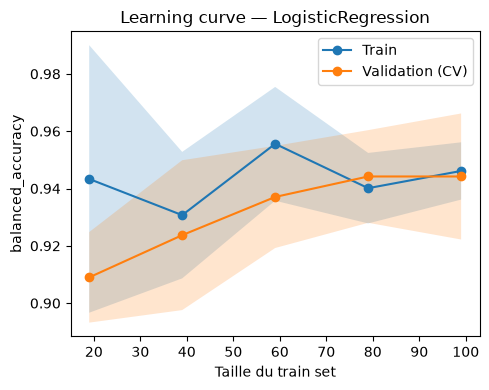


=== SVM_RBF ===


c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1

Meilleurs params : {'clf__C': 100, 'clf__gamma': 0.1}
Meilleur score CV : 0.958 ±  0.006
Score sur test set : 0.931


c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1

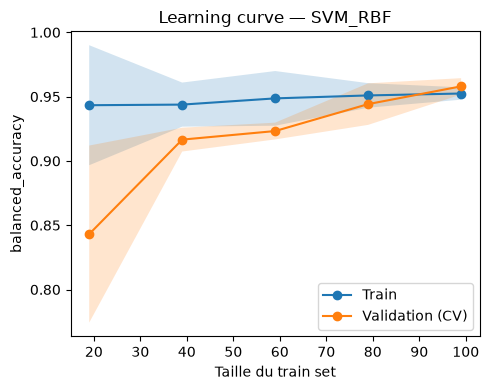


=== RandomForest ===
Meilleurs params : {'clf__max_depth': None, 'clf__min_samples_leaf': 5, 'clf__n_estimators': 100}
Meilleur score CV : 0.956 ±  0.029
Score sur test set : 0.931


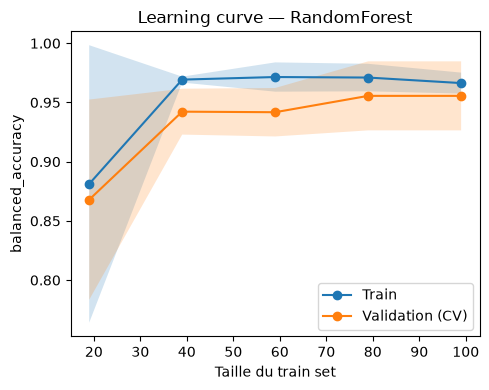


=== HistGradientBoosting ===
Meilleurs params : {'clf__learning_rate': 0.01, 'clf__max_depth': None, 'clf__max_iter': 100}
Meilleur score CV : 0.963 ±  0.034
Score sur test set : 0.931


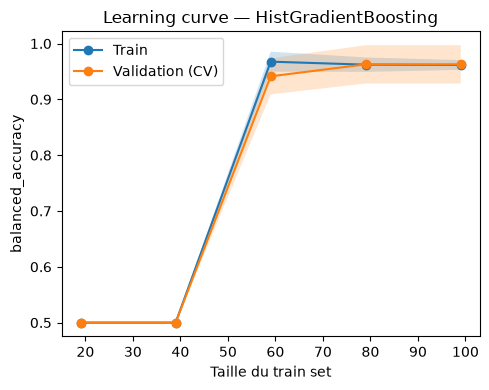


=== Comparaison des modèles ===
                      CV score    CV std  Test score
HistGradientBoosting  0.962727  0.034305    0.930588
SVM_RBF               0.958009  0.006364    0.930588
RandomForest          0.955584  0.029129    0.930588
LogisticRegression    0.944199  0.021986    0.910588

Meilleur modèle : HistGradientBoosting
              precision    recall  f1-score   support

           0       0.96      0.92      0.94        25
           1       0.89      0.94      0.91        17

    accuracy                           0.93        42
   macro avg       0.92      0.93      0.93        42
weighted avg       0.93      0.93      0.93        42



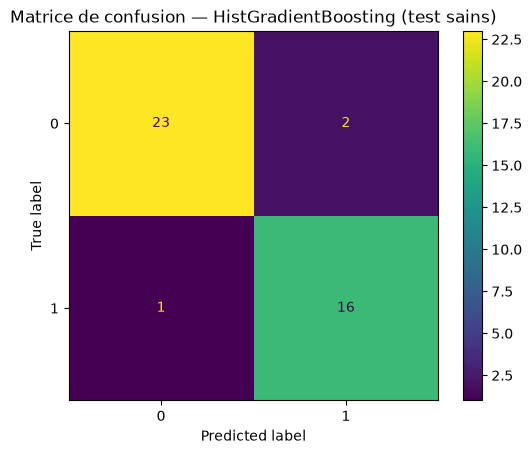

Meilleur modèle pour periph_sz : HistGradientBoosting

========================= periph_mdd =========================


c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


cluster
0    72
1    94
Name: count, dtype: int64
Cluster 0: 72 participants (group 0: 72)
Cluster 1: 94 participants (group 0: 94)

=== LogisticRegression ===
Meilleurs params : {'clf__C': 0.1, 'clf__penalty': 'l2'}
Meilleur score CV : 0.96 ±  0.043
Score sur test set : 0.972


c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Li

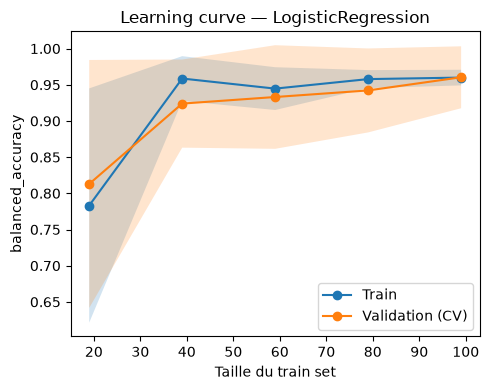


=== SVM_RBF ===


c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1

Meilleurs params : {'clf__C': 1, 'clf__gamma': 1}
Meilleur score CV : 0.96 ±  0.043
Score sur test set : 0.972


c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1

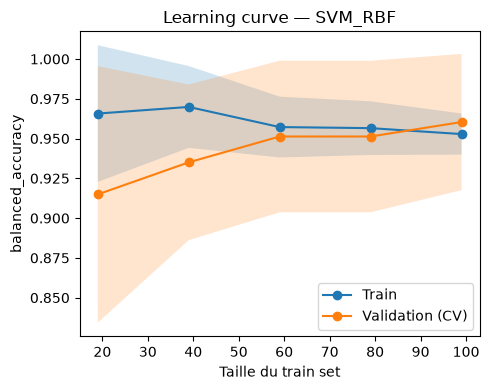


=== RandomForest ===
Meilleurs params : {'clf__max_depth': None, 'clf__min_samples_leaf': 10, 'clf__n_estimators': 100}
Meilleur score CV : 0.94 ±  0.076
Score sur test set : 0.924


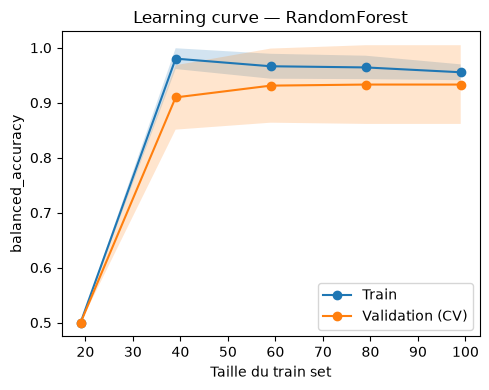


=== HistGradientBoosting ===
Meilleurs params : {'clf__learning_rate': 0.01, 'clf__max_depth': None, 'clf__max_iter': 100}
Meilleur score CV : 0.945 ±  0.073
Score sur test set : 0.896


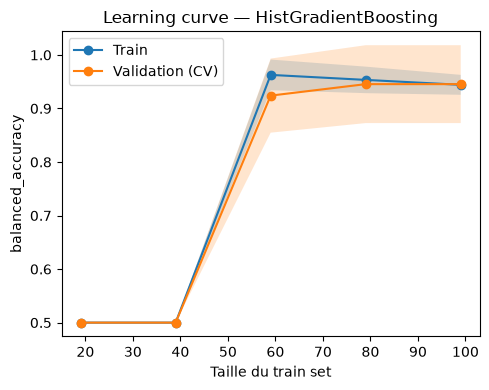


=== Comparaison des modèles ===
                      CV score    CV std  Test score
LogisticRegression    0.960390  0.042798    0.972222
SVM_RBF               0.960390  0.042798    0.972222
HistGradientBoosting  0.945455  0.072727    0.895833
RandomForest          0.940260  0.075993    0.923611

Meilleur modèle : LogisticRegression
              precision    recall  f1-score   support

           0       1.00      0.94      0.97        18
           1       0.96      1.00      0.98        24

    accuracy                           0.98        42
   macro avg       0.98      0.97      0.98        42
weighted avg       0.98      0.98      0.98        42



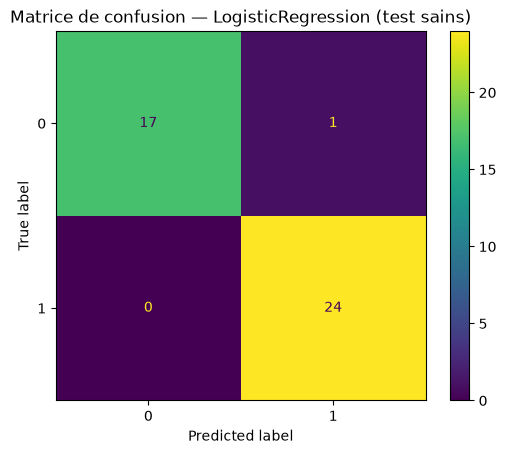

Meilleur modèle pour periph_mdd : LogisticRegression

========================= periph_man =========================


c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


cluster
0     65
1    101
Name: count, dtype: int64
Cluster 0: 65 participants (group 0: 65)
Cluster 1: 101 participants (group 0: 101)

=== LogisticRegression ===
Meilleurs params : {'clf__C': 1, 'clf__penalty': 'l2'}
Meilleur score CV : 0.966 ±  0.032
Score sur test set : 0.942


c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Li

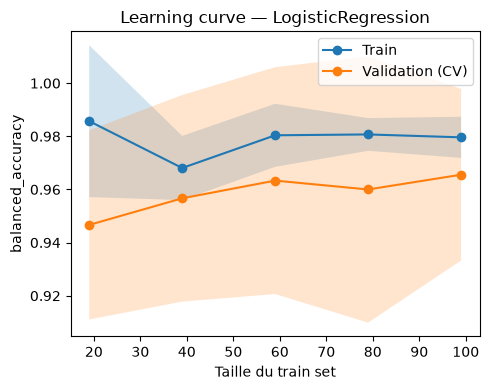


=== SVM_RBF ===


c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1

Meilleurs params : {'clf__C': 1, 'clf__gamma': 0.1}
Meilleur score CV : 0.966 ±  0.033
Score sur test set : 0.923


c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1

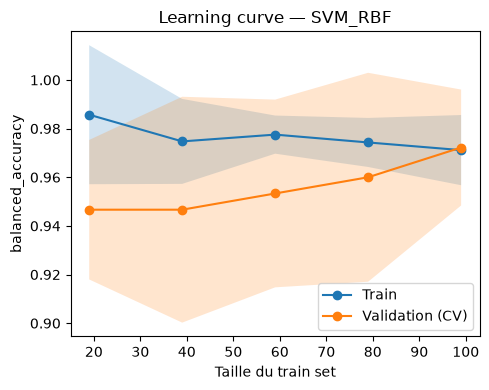


=== RandomForest ===
Meilleurs params : {'clf__max_depth': 3, 'clf__min_samples_leaf': 5, 'clf__n_estimators': 300}
Meilleur score CV : 0.956 ±  0.045
Score sur test set : 0.93


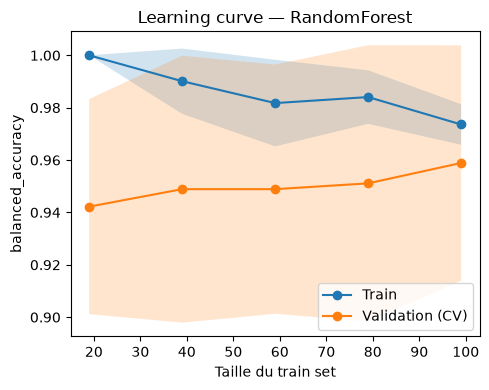


=== HistGradientBoosting ===
Meilleurs params : {'clf__learning_rate': 0.01, 'clf__max_depth': None, 'clf__max_iter': 400}
Meilleur score CV : 0.966 ±  0.033
Score sur test set : 0.942


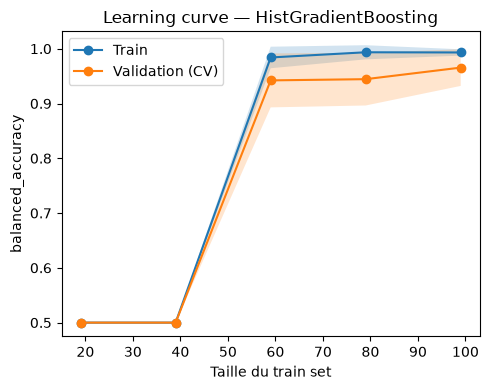


=== Comparaison des modèles ===
                      CV score    CV std  Test score
LogisticRegression    0.965556  0.032280    0.942308
SVM_RBF               0.965556  0.033407    0.923077
HistGradientBoosting  0.965556  0.033407    0.942308
RandomForest          0.955556  0.044859    0.930288

Meilleur modèle : LogisticRegression
              precision    recall  f1-score   support

           0       0.84      1.00      0.91        16
           1       1.00      0.88      0.94        26

    accuracy                           0.93        42
   macro avg       0.92      0.94      0.93        42
weighted avg       0.94      0.93      0.93        42



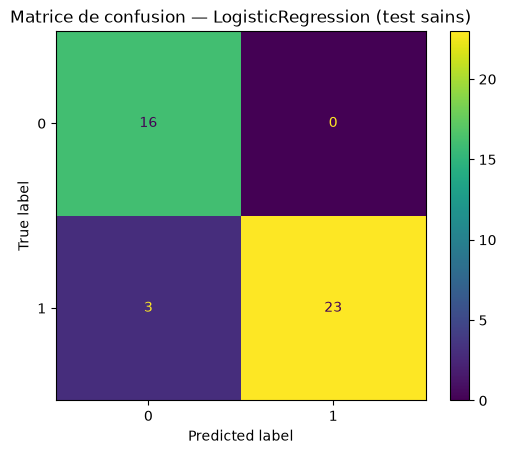

Meilleur modèle pour periph_man : LogisticRegression

========================= periph_ptsd =========================


c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


cluster
0    98
1    68
Name: count, dtype: int64
Cluster 0: 98 participants (group 0: 98)
Cluster 1: 68 participants (group 0: 68)

=== LogisticRegression ===
Meilleurs params : {'clf__C': 1, 'clf__penalty': 'l2'}
Meilleur score CV : 0.956 ±  0.032
Score sur test set : 0.971


c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Li

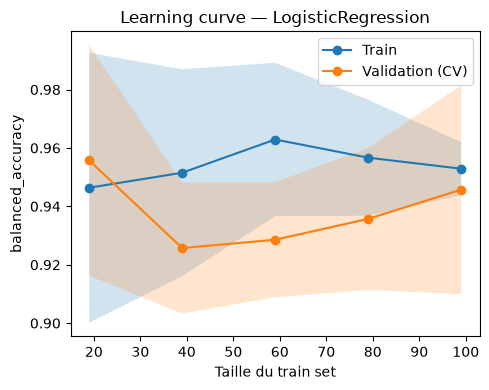


=== SVM_RBF ===


c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1

Meilleurs params : {'clf__C': 1, 'clf__gamma': 0.1}
Meilleur score CV : 0.956 ±  0.032
Score sur test set : 0.971


c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1

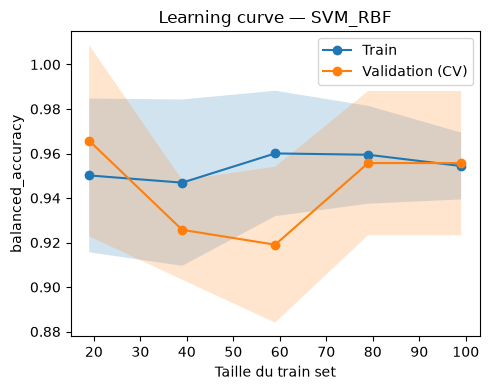


=== RandomForest ===
Meilleurs params : {'clf__max_depth': None, 'clf__min_samples_leaf': 5, 'clf__n_estimators': 100}
Meilleur score CV : 0.918 ±  0.048
Score sur test set : 0.971


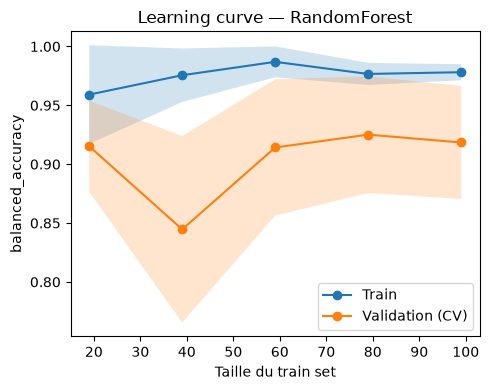


=== HistGradientBoosting ===
Meilleurs params : {'clf__learning_rate': 0.05, 'clf__max_depth': None, 'clf__max_iter': 200}
Meilleur score CV : 0.925 ±  0.052
Score sur test set : 0.971


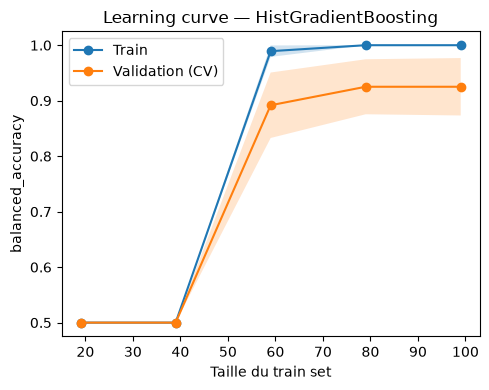


=== Comparaison des modèles ===
                      CV score    CV std  Test score
LogisticRegression    0.955714  0.032388    0.970588
SVM_RBF               0.955714  0.032388    0.970588
HistGradientBoosting  0.925108  0.051765    0.970588
RandomForest          0.918442  0.047992    0.970588

Meilleur modèle : LogisticRegression
              precision    recall  f1-score   support

           0       0.96      1.00      0.98        25
           1       1.00      0.94      0.97        17

    accuracy                           0.98        42
   macro avg       0.98      0.97      0.98        42
weighted avg       0.98      0.98      0.98        42



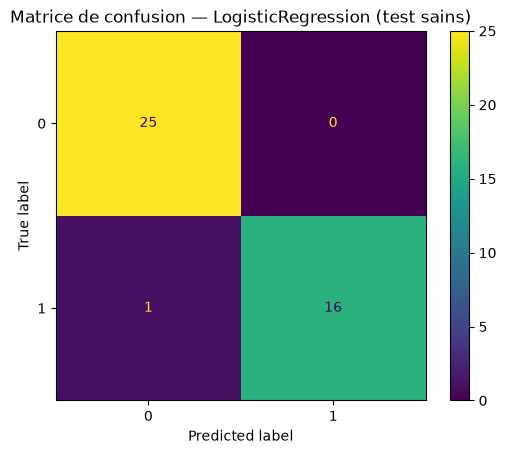

Meilleur modèle pour periph_ptsd : LogisticRegression


In [18]:
from umap_clustering import run_umap_clustering
from machinelearning import train_and_compare_classifiers, apply_to_patients

resultats_sous_echelles = {}

for nom, df_sains in sous_echelles_red.items():
    print(f"\n{'='*25} {nom} {'='*25}")

    df_patients = sous_echelles_PD_red[f"{nom}_PD"]

    # UMAP + KMeans fit sur TOUS les participants sains 
    result = run_umap_clustering(
        df_sains, n_clusters=2, random_state=42, group=group, show=False,
    )

    # Split train/test des sains SUR les projections/labels déjà calculés (pour le classifieur)
    X_all = result.proj_2d
    y_all = result.clusters
    idx_all = df_sains.index

    X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
        X_all, y_all, idx_all,
        test_size=0.25,
        random_state=42,
        stratify=y_all,
    )

    # Entraîner et comparer les classifieurs
    results, summary, best_model_name, best_model = train_and_compare_classifiers(
        X_train, y_train, X_test, y_test,
        scoring="balanced_accuracy",
        plot_curves=True,
    )

    # Application aux patients (transform UMAP + predict, jamais refit)
    df_patients_pred = apply_to_patients(
        best_model=best_model,
        umap_model=result.umap_2d_model,
        df_red_pd=df_patients,
    )

    resultats_sous_echelles[nom] = {
        "result": result,             
        "X_train": X_train, "X_test": X_test,
        "y_train": y_train, "y_test": y_test,
        "idx_train": idx_train, "idx_test": idx_test,
        "results": results,
        "summary": summary,
        "best_model_name": best_model_name,
        "best_model": best_model,
        "df_patients_pred": df_patients_pred,
    }

    print(f"Meilleur modèle pour {nom} : {best_model_name}")

clairement overfit le mod ne foncctionne pas : surtout pour core manie et periph mdd. 

# Récap des meilleurs modeles trouvés pour chq sous echelle

In [19]:
recap = []
for nom, r in resultats_sous_echelles.items():
    best_row = r["summary"].loc[r["best_model_name"]]
    patient_counts = r["df_patients_pred"]["predicted_cluster"].value_counts().sort_index()
    recap.append({
        "sous_echelle": nom,
        "best_model": r["best_model_name"],
        "cv_score": round(best_row["CV score"], 3),
        "test_score": round(best_row["Test score"], 3),
        "patients_cluster_0": patient_counts.get(0, 0),
        "patients_cluster_1": patient_counts.get(1, 0),
    })

df_recap = pd.DataFrame(recap).sort_values("test_score", ascending=False)
df_recap

,sous_echelle,best_model,cv_score,test_score,patients_cluster_0,patients_cluster_1
3,core_man,HistGradientBoosting,1.000,0.975,14,21
7,periph_mdd,LogisticRegression,0.960,0.972,21,14
9,periph_ptsd,LogisticRegression,0.956,0.971,13,22
4,core_ptsd,HistGradientBoosting,0.980,0.971,22,13
1,core_sz,RandomForest,0.954,0.946,14,21
8,periph_man,LogisticRegression,0.966,0.942,23,12
6,periph_sz,HistGradientBoosting,0.963,0.931,14,21
5,periph_ax,SVM_RBF,0.952,0.892,26,9
0,core_ax,SVM_RBF,0.951,0.854,21,14
2,core_mdd,SVM_RBF,0.971,0.821,19,16


# Visualisation de la classification des participants avec diag dans l'espace UMAP

In [20]:
import pandas as pd
import plotly.express as px

for nom, r in resultats_sous_echelles.items():
    result = r["result"]
    df_patients_pred = r["df_patients_pred"]
    df_patients = sous_echelles_PD_red[f"{nom}_PD"]

    X_patients_umap = result.umap_2d_model.transform(df_patients.values)

    hover_train = [f"Participant {i}" for i in r["idx_train"]]
    hover_test  = [f"Participant {i}" for i in r["idx_test"]]
    hover_diag  = [f"Participant {i}" for i in df_patients.index]

    df_plot = pd.concat([
        pd.DataFrame({
            "x": r["X_train"][:, 0], "y": r["X_train"][:, 1],
            "cluster": r["y_train"].astype(str),
            "type": "Sains (train)",
            "participant": hover_train,
        }),
        pd.DataFrame({
            "x": r["X_test"][:, 0], "y": r["X_test"][:, 1],
            "cluster": r["y_test"].astype(str),
            "type": "Sains (test)",
            "participant": hover_test,
        }),
        pd.DataFrame({
            "x": X_patients_umap[:, 0], "y": X_patients_umap[:, 1],
            "cluster": df_patients_pred["predicted_cluster"].astype(str),
            "type": "Diag",
            "participant": hover_diag,
        }),
    ], ignore_index=True)

    fig = px.scatter(
        df_plot, x="x", y="y",
        color="cluster", symbol="type",
        color_discrete_map={"0": "#A777F1", "1": "#FC6955"},
        symbol_map={"Sains (train)": "circle", "Sains (test)": "circle-open", "Diag": "triangle-up"},
        opacity=0.7,
        hover_name="participant",
        title=f"{nom} — Sains (train/test) et patients projetés dans l'espace UMAP (fit sur tous les sains)",
    )

    for trace in fig.data:
        if "Diag" in trace.name:
            trace.marker.line = dict(width=1, color="black")

    fig.show(renderer="browser")

# Regardons si le profil des participants avec diag mis dans le cluster 1 correspond à leur diag en fonction des sous echelles

In [25]:
col_name = df_PD.columns[18]
print(f"Colonne diag : {col_name}")

diag = df_PD[col_name]
repartition_patients = {}

for nom, r in resultats_sous_echelles.items():
    df_patients_pred = r["df_patients_pred"]

    # Items complets (non réduits) de la sous-échelle -> calcul du score normalisé (Northoff)
    df_items_nom = sous_echelles_PD[f"{nom}_PD"]
    n_items = df_items_nom.shape[1]
    score_nom = df_items_nom.sum(axis=1) / (10 * n_items)

    cluster_0_idx = df_patients_pred[df_patients_pred["predicted_cluster"] == 0].index
    cluster_1_idx = df_patients_pred[df_patients_pred["predicted_cluster"] == 1].index

    cluster_0 = list(zip(
        cluster_0_idx,
        diag.reindex(cluster_0_idx),
        score_nom.reindex(cluster_0_idx),
    ))
    cluster_1 = list(zip(
        cluster_1_idx,
        diag.reindex(cluster_1_idx),
        score_nom.reindex(cluster_1_idx),
    ))

    repartition_patients[nom] = {
        "cluster_0": cluster_0,
        "cluster_1": cluster_1,
    }

    print(f"\n{'='*25} {nom} {'='*25}")
    print(f"Cluster 0 ({len(cluster_0)} patients) :")
    for participant, d, s in cluster_0:
        print(f"  Participant {participant} → {d} | score {nom} = {s:.3f}")
    print(f"Cluster 1 ({len(cluster_1)} patients) :")
    for participant, d, s in cluster_1:
        print(f"  Participant {participant} → {d} | score {nom} = {s:.3f}")


lignes = []
for nom, r in repartition_patients.items():
    for cl in ["cluster_0", "cluster_1"]:
        scores = pd.Series([s for _, _, s in r[cl]], dtype=float)
        lignes.append({
            "sous_echelle": nom,
            "cluster": cl,
            "n": len(scores),
            "moyenne": scores.mean(),
            "min": scores.min(),
            "max": scores.max(),
        })

stats_clusters_PD = pd.DataFrame(lignes).round(3)
print(stats_clusters_PD.to_string(index=False))

Colonne diag : Si oui, lequel (lesquels) ? 

========================= core_ax =========================
Cluster 0 (21 patients) :
  Participant 4 → Trouble anxieux | score core_ax = 0.550
  Participant 13 → Dépression | score core_ax = 0.657
  Participant 20 → TROUBLE BIPOLAIRE TYPE 1 | score core_ax = 0.386
  Participant 28 → épisode dépressif caractérisé | score core_ax = 0.586
  Participant 113 → Dépression | score core_ax = 0.407
  Participant 140 → Dépression, anxiété, TdAH | score core_ax = 0.500
  Participant 149 → Diagnostic d’un trouble anxieux et généralisé | score core_ax = 0.457
  Participant 176 → TSA, TDAH, TDI, bipolarité type 1 | score core_ax = 0.764
  Participant 178 → TAG | score core_ax = 0.529
  Participant 182 → Dépression | score core_ax = 0.571
  Participant 195 → Syndrome anxio dépressif | score core_ax = 0.443
  Participant 209 → Dépression | score core_ax = 0.557
  Participant 242 → Episode depressif modéré | score core_ax = 0.443
  Participant 247 → TDAH et

Finalement le cluster 0 ou 1 change : le + ou - symptomatique selon les df. Globalement apres analyse: les items spé de la /// sont représentatifs de ... 
Attention, les modèles ont surappris, on a pas assez d'echantillon et encore moins de patients! 

# SFS - Sequential Feature Selection - backward

Boucle pour chaque type de patho (sauf comorbidité qui ne faisait pas partie de l'echelle) : 
Par exemple, on prend les patients MDD qu'on renomme "1" et tous les controles "0", sur les 40 items. On entraine un classifier sur tout (split train/test sur les 2 groupes )avec cv = stratifiedKfold car groupes non equilibrés. Puis on rgerade si classifier capable de classer 0 et 1. Va me sortir les items spé des patients MDD avec le SFS. A comparer avec ceux établis par Northoff 

In [24]:
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import balanced_accuracy_score, classification_report
import numpy as np

# Groupes diagnostiques 
sz    = df_PD.iloc[[10]]
man   = df_PD.iloc[[4, 21, 22, 26, 29, 30]]
ax    = df_PD.iloc[[1, 12, 13, 15, 24]]
dep   = df_PD.iloc[[2, 3, 5, 6, 7, 8, 9, 16, 18, 19, 28]]
comor = df_PD.iloc[[0, 11, 14, 17, 20, 23, 25, 27]]

# Mapping des noms des sous-échelle -> groupe patients ciblé + items core/periph prédéfinis
diag_map = {
    "mdd":  {"idx_target": dep.index,  "items_core": items_core_md, "items_periph": items_per_md},
    "sz":   {"idx_target": sz.index,   "items_core": items_core_sz, "items_periph": items_per_sz},
    "man":  {"idx_target": man.index,  "items_core": items_core_ma, "items_periph": items_per_ma},
    "ax":   {"idx_target": ax.index,   "items_core": items_core_an, "items_periph": items_per_an},
}

items_40 = [f"TSQ{i}" for i in range(1, 41)]
df_healthy_40 = df_TSQ[items_40]   

resultats_sfs_diag = {}

for nom, cfg in diag_map.items():
    print(f"\n{'='*25} {nom.upper()} {'='*25}")

    idx_target = cfg["idx_target"]
    idx_common = df_TSQ_PD.index.intersection(idx_target)
    df_patients_target = df_TSQ_PD.loc[idx_common, items_40]

    print(f"{len(df_patients_target)} patients '{nom}' trouvés / {len(idx_target)} attendus")

    if len(df_patients_target) < 5:
        print(f"Trop peu de patients '{nom}' ({len(df_patients_target)}) pour un split fiable, on passe.")
        continue

    # Dataset binaire : 0 = sain, 1 = diag ciblé, sur les 40 items
    X_full = pd.concat([df_healthy_40, df_patients_target], axis=0)
    y_full = np.array([0] * len(df_healthy_40) + [1] * len(df_patients_target))
    idx_full = X_full.index

    X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
        X_full, y_full, idx_full,
        test_size=0.25, random_state=42, stratify=y_full,
    )

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    clf = RandomForestClassifier(
        n_estimators=300, max_depth=5, min_samples_leaf=5,
        class_weight="balanced", random_state=42,
    )

    baseline_scores = cross_val_score(clf, X_train, y_train, cv=cv, scoring="balanced_accuracy")
    print(f"Score CV baseline (40 items) : {baseline_scores.mean():.3f} ± {baseline_scores.std():.3f}")

    sfs = SequentialFeatureSelector(
        clf, direction="backward", n_features_to_select="auto",#essayer de changer 5 par ex
        tol=-0.005, scoring="balanced_accuracy", cv=cv, n_jobs=-1,
    )
    sfs.fit(X_train, y_train)

    selected_items = list(X_train.columns[sfs.get_support()])
    print(f"Items sélectionnés par SFS ({len(selected_items)}/40) :", selected_items)

    clf.fit(X_train[selected_items], y_train)
    y_pred = clf.predict(X_test[selected_items])
    test_score = balanced_accuracy_score(y_test, y_pred)
    print(f"Score test (items SFS) : {test_score:.3f}")
    print(classification_report(y_test, y_pred))

    # Comparaison avec les items core/periphery prédéfinis par Northoff
    items_core = set(cfg["items_core"])
    items_periph = set(cfg["items_periph"])
    selected_set = set(selected_items)

    overlap_core = selected_set & items_core
    overlap_periph = selected_set & items_periph
    overlap_neither = selected_set - items_core - items_periph

    print(f"Overlap avec items_core_{nom} : {sorted(overlap_core)} ({len(overlap_core)}/{len(items_core)})")
    print(f"Overlap avec items_periph_{nom} : {sorted(overlap_periph)} ({len(overlap_periph)}/{len(items_periph)})")
    print(f"Items SFS hors core/periph prédéfinis : {sorted(overlap_neither)}")

    resultats_sfs_diag[nom] = {
        "n_patients": len(df_patients_target),
        "selected_items": selected_items,
        "baseline_cv_score": baseline_scores.mean(),
        "test_score_sfs": test_score,
        "overlap_core": overlap_core,
        "overlap_periph": overlap_periph,
        "idx_train": idx_train, "idx_test": idx_test,
        "sfs": sfs, "clf": clf,
    }


========================= MDD =========================
11 patients 'mdd' trouvés / 11 attendus
Score CV baseline (40 items) : 0.690 ± 0.218
Items sélectionnés par SFS (31/40) : ['TSQ2', 'TSQ3', 'TSQ4', 'TSQ5', 'TSQ6', 'TSQ7', 'TSQ8', 'TSQ9', 'TSQ11', 'TSQ12', 'TSQ14', 'TSQ16', 'TSQ17', 'TSQ19', 'TSQ20', 'TSQ21', 'TSQ23', 'TSQ24', 'TSQ25', 'TSQ27', 'TSQ28', 'TSQ29', 'TSQ30', 'TSQ31', 'TSQ32', 'TSQ33', 'TSQ34', 'TSQ36', 'TSQ37', 'TSQ38', 'TSQ40']
Score test (items SFS) : 0.417
              precision    recall  f1-score   support

           0       0.92      0.83      0.88        42
           1       0.00      0.00      0.00         3

    accuracy                           0.78        45
   macro avg       0.46      0.42      0.44        45
weighted avg       0.86      0.78      0.82        45

Overlap avec items_core_mdd : ['TSQ14', 'TSQ17', 'TSQ25', 'TSQ28', 'TSQ29', 'TSQ36', 'TSQ9'] (7/7)
Overlap avec items_periph_mdd : ['TSQ12', 'TSQ16', 'TSQ19', 'TSQ2', 'TSQ20', 'TSQ23', 'TSQ27

c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\model_selection\_split.py:812: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\metrics\_classification.py:2939: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


Score CV baseline (40 items) : 0.580 ± 0.191


c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\model_selection\_split.py:812: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\model_selection\_split.py:812: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\model_selection\_split.py:812: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\model_selection\_split.py:812: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\model_selection\_split.py:812: UserWarning: The least populated class in y has only 4 members, which is less than n_sp

Items sélectionnés par SFS (31/40) : ['TSQ2', 'TSQ3', 'TSQ5', 'TSQ6', 'TSQ7', 'TSQ8', 'TSQ9', 'TSQ10', 'TSQ12', 'TSQ13', 'TSQ14', 'TSQ16', 'TSQ17', 'TSQ18', 'TSQ20', 'TSQ21', 'TSQ22', 'TSQ23', 'TSQ25', 'TSQ26', 'TSQ28', 'TSQ29', 'TSQ30', 'TSQ31', 'TSQ32', 'TSQ33', 'TSQ34', 'TSQ35', 'TSQ38', 'TSQ39', 'TSQ40']
Score test (items SFS) : 0.488
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.00      0.00      0.00         1

    accuracy                           0.95        43
   macro avg       0.49      0.49      0.49        43
weighted avg       0.95      0.95      0.95        43

Overlap avec items_core_ax : ['TSQ13', 'TSQ16', 'TSQ17', 'TSQ20', 'TSQ23', 'TSQ33', 'TSQ35', 'TSQ38', 'TSQ39', 'TSQ5', 'TSQ6', 'TSQ9'] (12/14)
Overlap avec items_periph_ax : ['TSQ12', 'TSQ18', 'TSQ2', 'TSQ22', 'TSQ25', 'TSQ3', 'TSQ32'] (7/9)
Items SFS hors core/periph prédéfinis : ['TSQ10', 'TSQ14', 'TSQ21', 'TSQ26', 'TSQ28', 'TSQ

n'affichera pas pour les sz ni ptsd par exemple car trop peu de patients: ne sert a rien de split train/test

In [ ]:
recap_sfs_diag = pd.DataFrame({
    nom: {
        "n_patients": r["n_patients"],
        "n_items_selected": len(r["selected_items"]),
        "baseline_cv": round(r["baseline_cv_score"], 3),
        "test_score": round(r["test_score_sfs"], 3),
        "n_overlap_core": len(r["overlap_core"]),
        "n_overlap_periph": len(r["overlap_periph"]),
    }
    for nom, r in resultats_sfs_diag.items()
}).T

recap_sfs_diag

,n_patients,n_items_selected,baseline_cv,test_score,n_overlap_core,n_overlap_periph
mdd,11.0,37.0,0.535,0.667,6.0,10.0
man,6.0,20.0,0.483,0.974,3.0,5.0
ax,5.0,8.0,0.552,0.487,2.0,1.0


# RFECV - Recursive feature elimination with cross-validation to select features.

In [ ]:
%load_ext autoreload
%autoreload 2


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


cluster
0    57
1    97
Name: count, dtype: int64
Cluster 0: 57 participants (group 0: 57)
Cluster 1: 97 participants (group 0: 97)

=== LogisticRegression ===
Meilleurs params : {'clf__C': 0.1, 'clf__penalty': 'l2'}
Meilleur score CV : 0.951 ±  0.031
Score sur test set : 0.873


c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Li

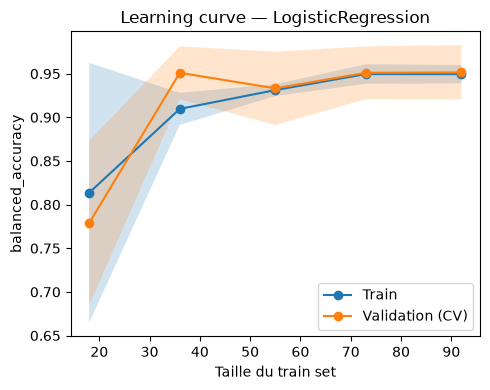


=== SVM_RBF ===


c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1

Meilleurs params : {'clf__C': 1, 'clf__gamma': 1}
Meilleur score CV : 0.964 ±  0.02
Score sur test set : 0.893


c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1

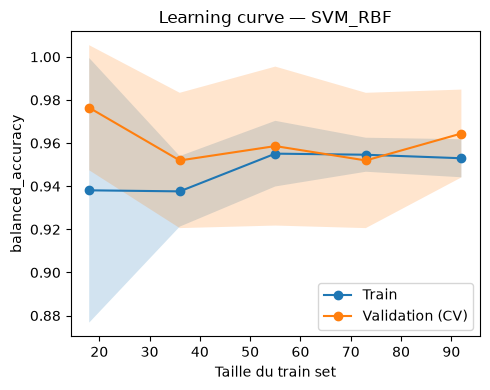


=== RandomForest ===
Meilleurs params : {'clf__max_depth': None, 'clf__min_samples_leaf': 5, 'clf__n_estimators': 100}
Meilleur score CV : 0.958 ±  0.024
Score sur test set : 0.929


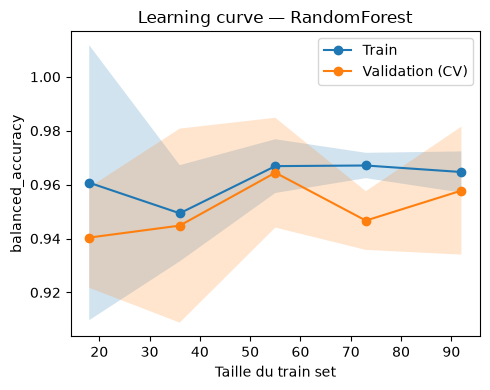


=== HistGradientBoosting ===
Meilleurs params : {'clf__learning_rate': 0.01, 'clf__max_depth': None, 'clf__max_iter': 100}
Meilleur score CV : 0.947 ±  0.037
Score sur test set : 0.929


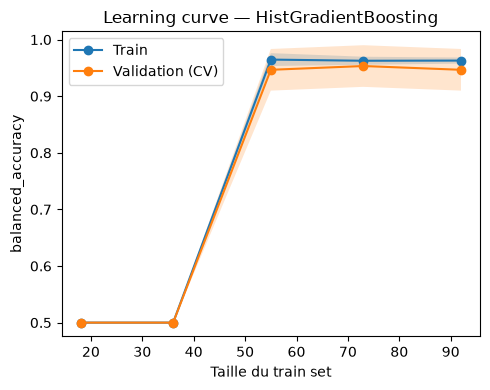


=== Comparaison des modèles ===
                      CV score    CV std  Test score
SVM_RBF               0.964444  0.020367    0.892857
RandomForest          0.957778  0.023727    0.928571
LogisticRegression    0.951468  0.031163    0.872857
HistGradientBoosting  0.946667  0.036784    0.928571

Meilleur modèle : SVM_RBF
              precision    recall  f1-score   support

           0       1.00      0.79      0.88        14
           1       0.89      1.00      0.94        25

    accuracy                           0.92        39
   macro avg       0.95      0.89      0.91        39
weighted avg       0.93      0.92      0.92        39



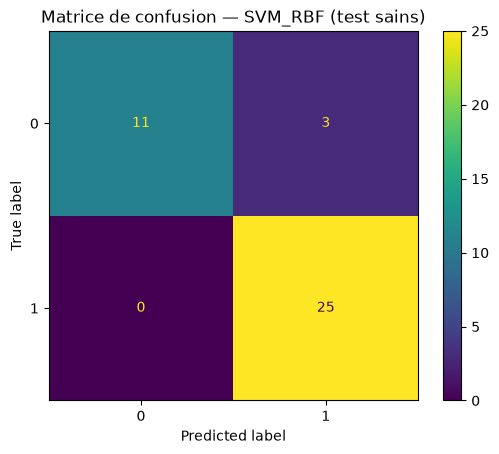

[UMAP 2D] Meilleur modèle : SVM_RBF
                      CV score    CV std  Test score
SVM_RBF               0.964444  0.020367    0.892857
RandomForest          0.957778  0.023727    0.928571
LogisticRegression    0.951468  0.031163    0.872857
HistGradientBoosting  0.946667  0.036784    0.928571
Nombre optimal d'items : 40
Score CV (balanced accuracy) : 0.963
Score test (items sélectionnés) : 0.964

Items sélectionnés, par importance décroissante :
TSQ39    0.077197
TSQ26    0.070167
TSQ15    0.059839
TSQ36    0.059194
TSQ19    0.051942
TSQ34    0.046147
TSQ22    0.045942
TSQ10    0.040890
TSQ25    0.038385
TSQ38    0.037337
TSQ33    0.035872
TSQ3     0.032946
TSQ1     0.029796
TSQ9     0.029644
TSQ35    0.029152
TSQ30    0.027052
TSQ32    0.025500
TSQ24    0.024923
TSQ8     0.024265
TSQ5     0.024014
TSQ28    0.022234
TSQ37    0.021889
TSQ20    0.019434
TSQ18    0.019046
TSQ13    0.016276
TSQ40    0.012361
TSQ17    0.011938
TSQ31    0.010749
TSQ27    0.008833
TSQ16    0.006784
TSQ

In [ ]:
import rfecv as prg

resultats_analyse = prg.run_full_analysis(
    df_PD=df_PD,
    df_sains_40=df_TSQ,
    df_red_sains=df_red_sains,
    df_pd_40=df_TSQ_PD,
    df_red_pd=df_red_pd,
    group=group,
    items_core_sz=items_core_sz,
    items_core_ma=items_core_ma,
    items_core_an=items_core_an,
    items_core_md=items_core_md,
)
recaps = resultats_analyse["recaps"]